# Traffic Accident Severity Prediction
### CSAI-801 — Machine Learning Project 

**Dataset:** Toronto Accidents
**Goal:** Predict whether an accident is Low severity (levels 1-2) or High severity (levels 3-4)  
**Main Models:** Random Forest and Gradient Boosting  

---

### What this notebook does

Traffic accidents are a serious problem — around 38,000 people die on Canadian roads every year. Being able to predict how severe an accident is, right when it happens, could help emergency teams respond faster and save lives.

In this project we use a dataset of 7.7 million Toronto accidents to build a classifier that predicts whether an accident will be low severity or high severity. We only use features that would be available at the scene (weather, time of day, road type, etc.) — not hospital records.

### The steps we follow
1. Load the data and create a balanced sample
2. Split into train and test sets RIGHT AWAY (before doing anything else)
3. Explore the training data (EDA)
4. Build a preprocessing pipeline
5. Try a few baseline models
6. Train and tune Random Forest
7. Train and tune Gradient Boosting
8. Compare them and try ensemble methods
9. Look at which features matter most
10. Wrap up with conclusions


---
## 0. Imports and Settings

In [1]:
# these are all the libraries we need for the whole project
# pandas and numpy are for handling data
# matplotlib and seaborn are for making charts
# sklearn has all the machine learning tools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
import os

# suppress warnings so the output stays clean
warnings.filterwarnings('ignore')

# sklearn preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

# sklearn models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

# metrics to evaluate models
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# ---- project settings ----
# putting constants up here makes it easy to change them later

RANDOM_STATE = 42          # seed for reproducibility
SAMPLES_PER_CLASS = 62000  # how many rows we keep per severity level
TEST_SIZE = 0.20           # 20% of data goes to the test set
TRAIN_CSV = 'train_data.csv'
TEST_CSV = 'test_data.csv'

# make pandas show more columns
pd.set_option('display.max_columns', 50)

# chart styling
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
sns.set_palette('Set2')

import sklearn
print('All libraries loaded!')
print('pandas version:', pd.__version__)
print('numpy version:', np.__version__)
print('sklearn version:', sklearn.__version__)


All libraries loaded!
pandas version: 2.3.3
numpy version: 2.3.5
sklearn version: 1.7.2


---
## 1. Load Data, Clean It, and Split Into Train/Test

The dataset is from: https://data.torontopolice.on.ca/datasets/TorontoPS::traffic-collisions-open-data-asr-t-tbl-001/about
Download `Traffic_Collisions_Open_Data.csv` and put it in the same folder as this notebook.

**Important:** We do the train/test split BEFORE doing any EDA or feature engineering.  
This is called a 'split-first' approach and it prevents a common mistake called data leakage —  
where information from the test set accidentally influences how we build the model.

Steps:
1. Load the CSV
2. Remove duplicate rows
3. Remove rows that have missing values
4. Take a balanced sample (62,000 rows per severity class)
5. Split into train and test
6. Save both splits to CSV files


In [2]:
# the original file 
 
df_raw = pd.read_csv('Traffic_Collisions_Open_Data.csv')
print('Data Shape:', df_raw.shape)


Data Shape: (7728394, 33)


In [3]:
# step 1: remove duplicate rows
df_raw = df_raw.drop_duplicates()
df_raw = df_raw.reset_index(drop=True)
print(f'Data Shape after dropping Duplicates {df_raw.shape}')


Data Shape after dropping Duplicates (7728394, 33)


In [4]:
# step 2: drop rows with any missing values
# we have so many rows that we can afford to just drop them because data is big enough
df_raw = df_raw.dropna()
df_raw = df_raw.reset_index(drop=True)
print(f'Data Shape after dropping Nulls {df_raw.shape}')



Data Shape after dropping Nulls (5217919, 33)


In [5]:
# step 3: check the severity distribution before sampling
# the dataset is heavily imbalanced — Severity 2 has way more rows than the others
# if we train on this imbalanced data, the model will just predict 'Severity 2' for everything
print('Severity distribution BEFORE balancing:')

df_raw['Severity'].value_counts(normalize=True)

Severity distribution BEFORE balancing:


Severity
2    0.852238
3    0.111899
4    0.023973
1    0.011891
Name: proportion, dtype: float64

In [6]:
# step 4: take a balanced sample of 62,000 rows per severity class
# this gives us 248,000 total rows with equal representation of each severity

balanced_parts = []

for severity_level in sorted(df_raw['Severity'].unique()):
    # get all rows for this severity level
    subset = df_raw[df_raw['Severity'] == severity_level]
    # sample 62,000 (or all of them if fewer exist)
    sampled = subset.sample(n=min(len(subset), SAMPLES_PER_CLASS), random_state=RANDOM_STATE)
    balanced_parts.append(sampled)

# combine all the sampled parts into one dataframe
df = pd.concat(balanced_parts)
df = df.sample(frac=1, random_state=RANDOM_STATE)  # shuffle the rows
df = df.reset_index(drop=True)

# free memory since we don't need the big raw dataframe anymore
del df_raw

print('After balancing:')
print('Total rows:', len(df))
print('Distribution:')
for severity_level in sorted(df['Severity'].unique()):
    count = len(df[df['Severity'] == severity_level])
    pct = count / len(df) * 100
    print(f'  Severity {severity_level}: {count:,} rows ({pct:.1f}%)')


After balancing:
Total rows: 248000
Distribution:
  Severity 1: 62,000 rows (25.0%)
  Severity 2: 62,000 rows (25.0%)
  Severity 3: 62,000 rows (25.0%)
  Severity 4: 62,000 rows (25.0%)


In [7]:
# step 5: split into train (80%) and test (20%) BEFORE doing anything else
# stratify=df['Severity'] makes sure both splits have the same severity distribution

df_train, df_test = train_test_split(df,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=df['Severity'])

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print('\nSeverity distribution in train set:')
df_train['Severity'].value_counts(normalize=True)


Severity distribution in train set:


Severity
1    0.25
2    0.25
4    0.25
3    0.25
Name: proportion, dtype: float64

In [8]:
# step 6: save both splits to CSV so we can always reload them
# this also makes it clear that from now on, everything uses these files

df_train.to_csv(TRAIN_CSV, index=False)
df_test.to_csv(TEST_CSV, index=False)

print('Saved train data to:', TRAIN_CSV)
print('Saved test data to:', TEST_CSV)
print()
print('From now on, all EDA and preprocessing will only use the training data.')
print('The test set stays locked away until the final evaluation.')


Saved train data to: train_data.csv
Saved test data to: test_data.csv

From now on, all EDA and preprocessing will only use the training data.
The test set stays locked away until the final evaluation.


---
## 2. Exploratory Data Analysis (EDA)

We look at the training data to understand what we're working with.
We check the shape, the data types, missing values, and make some charts.


In [9]:
# reload the saved CSV files
# we do this to make sure the notebook can be rerun from this point
df_train = pd.read_csv(TRAIN_CSV, low_memory=False)
df_test = pd.read_csv(TEST_CSV, low_memory=False)

print('Training set loaded:', df_train.shape)
print('Test set loaded:', df_test.shape)


Training set loaded: (198400, 33)
Test set loaded: (49600, 33)


In [10]:
# 2.1 basic info about the training data
# this shows us column names and data types
df_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198400 entries, 0 to 198399
Data columns (total 33 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     198400 non-null  object 
 1   Source                 198400 non-null  object 
 2   Severity               198400 non-null  int64  
 3   Start_Time             198400 non-null  object 
 4   End_Time               198400 non-null  object 
 5   Distance(mi)           198400 non-null  float64
 6   Weather_Timestamp      198400 non-null  object 
 7   Temperature(F)         198400 non-null  float64
 8   Wind_Chill(F)          198400 non-null  float64
 9   Humidity(%)            198400 non-null  float64
 10  Pressure(in)           198400 non-null  float64
 11  Visibility(mi)         198400 non-null  float64
 12  Wind_Direction         198400 non-null  object 
 13  Wind_Speed(mph)        198400 non-null  float64
 14  Precipitation(in)      198400 non-nu

In [11]:
# 2.2 summary statistics for numeric columns
# this gives us the mean, min, max, etc. for each numeric column
df_train.describe(include='number')


,Severity,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,198400.000000,198400.000000,198400.000000,198400.000000,198400.000000,198400.000000,198400.000000,198400.000000,198400.000000
mean,2.500000,0.683408,63.397852,62.206118,65.060650,29.256846,9.077562,7.411214,0.006483
std,1.118037,2.395857,18.858683,21.000409,23.594994,1.203845,2.584236,5.455759,0.056195
min,1.000000,0.000000,-21.000000,-46.000000,2.000000,19.940000,0.000000,0.000000,0.000000
25%,1.750000,0.000000,51.000000,51.000000,48.000000,29.100000,10.000000,3.000000,0.000000
50%,2.500000,0.000000,66.000000,66.000000,68.000000,29.580000,10.000000,7.000000,0.000000
75%,3.250000,0.431000,77.000000,77.000000,85.000000,29.920000,10.000000,10.000000,0.000000
max,4.000000,251.220001,162.000000,162.000000,100.000000,31.080000,80.000000,232.000000,9.990000


In [12]:
# 2.3 summary for text/categorical columns
df_train.describe(include='object')


,ID,Source,Start_Time,End_Time,Weather_Timestamp,Wind_Direction,Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,198400,198400,198400,198400,198400,198400,198400,198400,198400,198400,198400
unique,198400,3,188000,190925,111961,23,92,2,2,2,2
top,A-634791,Source1,2021-11-21 18:37:51,2021-11-22 08:00:00,2021-11-21 18:45:00,CALM,Fair,Day,Day,Day,Day
freq,1,108671,51,51,58,33152,90905,139747,148448,157538,165031


In [13]:
# 2.4 check for missing values
# even though we dropped nulls earlier, it's good to double check

df_train.dropna(inplace=True)

In [14]:
# 2.5 preview the first few rows
df_train.head()


,ID,Source,Severity,Start_Time,End_Time,Distance(mi),Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-634791,Source2,1,2022-04-28 11:05:44,2022-04-28 11:51:27,0.000,2022-04-28 10:52:00,67.0,67.0,32.0,29.42,10.0,N,12.0,0.0,Partly Cloudy,False,False,False,False,False,True,False,False,False,False,False,False,False,Day,Day,Day,Day
1,A-522703,Source2,1,2022-08-30 07:11:51,2022-08-30 07:57:00,0.000,2022-08-30 06:53:00,73.0,73.0,84.0,29.37,10.0,S,5.0,0.0,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
2,A-7043533,Source1,1,2020-05-21 13:04:30,2020-05-21 13:19:30,0.000,2020-05-21 12:50:00,70.0,70.0,16.0,24.29,30.0,E,12.0,0.0,Fair,False,False,False,False,True,False,False,False,False,False,False,False,False,Day,Day,Day,Day
3,A-7095214,Source1,1,2020-06-17 11:56:35,2020-06-17 12:31:33,0.000,2020-06-17 11:53:00,66.0,66.0,54.0,30.28,10.0,VAR,5.0,0.0,Mostly Cloudy,False,False,True,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
4,A-3727427,Source1,2,2022-07-19 14:52:30,2022-07-19 17:25:30,1.331,2022-07-19 14:55:00,101.0,101.0,12.0,29.88,10.0,W,13.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day


In [15]:
# 2.6 check value counts for the most important columns

print('Severity distribution:')
df_train['Severity'].value_counts().sort_index()

Severity distribution:


Severity
1    49600
2    49600
3    49600
4    49600
Name: count, dtype: int64

In [16]:
print('Day or Night:')
df_train['Sunrise_Sunset'].value_counts()


Day or Night:


Sunrise_Sunset
Day      139747
Night     58653
Name: count, dtype: int64

In [17]:
print('Top 10 weather conditions:')
df_train['Weather_Condition'].value_counts().head(10)


Top 10 weather conditions:


Weather_Condition
Fair             90905
Cloudy           29636
Mostly Cloudy    27545
Partly Cloudy    18403
Light Rain       10304
Light Snow        4344
Fog               2760
Rain              2220
Fair / Windy      1261
Haze              1224
Name: count, dtype: int64

In [18]:
print('Top 10 wind directions:')
df_train['Wind_Direction'].value_counts().head(10)

Top 10 wind directions:


Wind_Direction
CALM    33152
S       16247
W       14365
SSW     11378
N       10918
SW      10701
WNW      9839
WSW      9826
NW       9701
E        9657
Name: count, dtype: int64

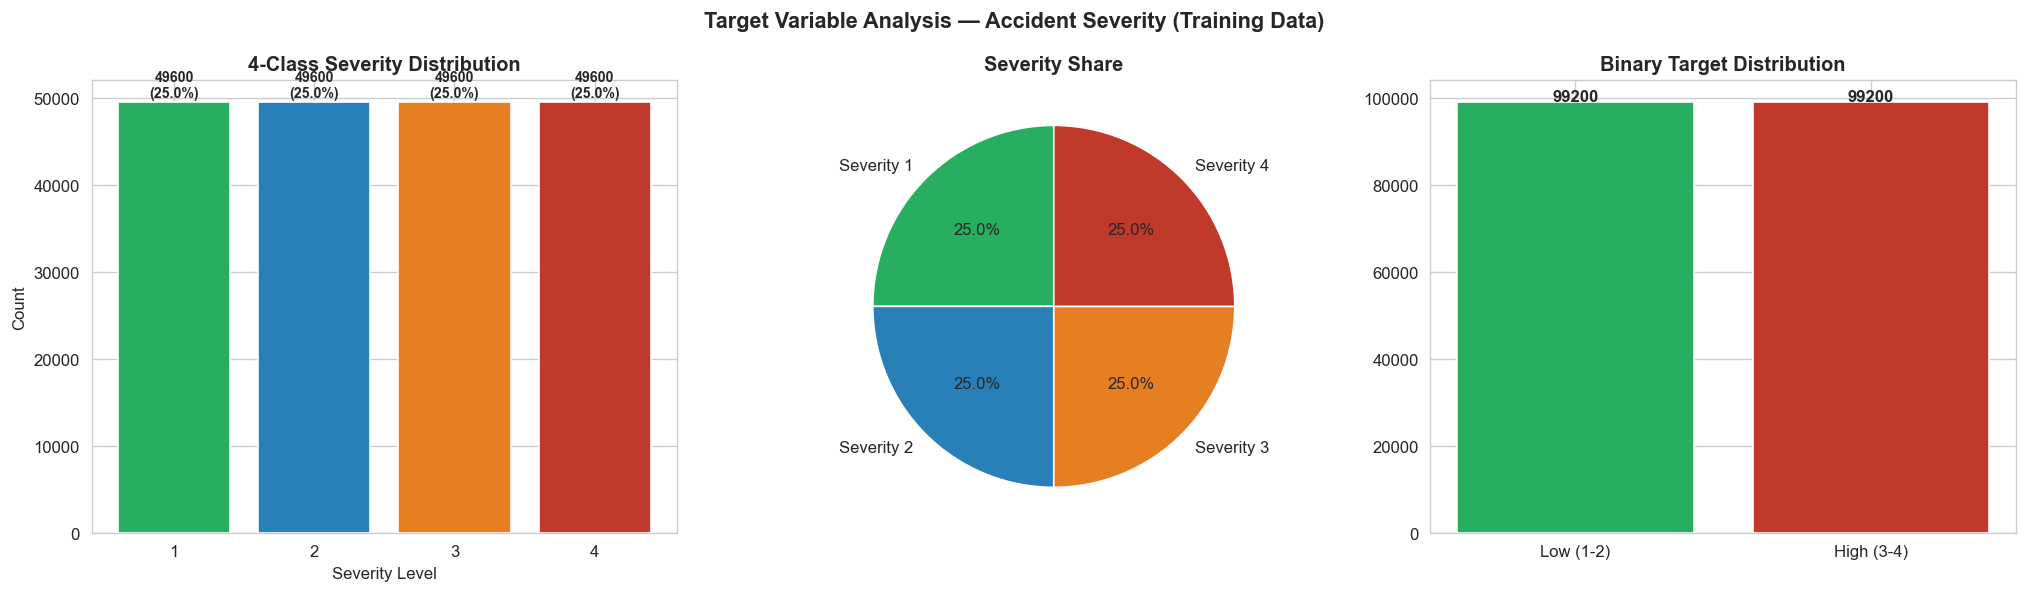

In [19]:
# 2.7 plot the target variable distribution
# we want to see both the 4-class version and the binary version we'll use for modeling

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# colors for the 4 severity levels
colors_sev = ['#27ae60', '#2980b9', '#e67e22', '#c0392b']

# left chart: bar chart of all 4 severity levels
sev_counts = df_train['Severity'].value_counts().sort_index()
bars = axes[0].bar(
    sev_counts.index.astype(str),
    sev_counts.values,
    color=colors_sev,
    edgecolor='white'
)

# add labels on top of each bar
for bar, val in zip(bars, sev_counts.values):
    label = str(val) + '\n(' + str(round(val / len(df_train) * 100, 1)) + '%)'
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        label,
        ha='center', va='bottom', fontsize=8.5, fontweight='bold'
    )

axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Count')
axes[0].set_title('4-Class Severity Distribution', fontweight='bold')

# middle chart: pie chart
axes[1].pie(
    sev_counts.values,
    labels=['Severity ' + str(s) for s in sev_counts.index],
    colors=colors_sev,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Severity Share', fontweight='bold')

# right chart: the binary version we will actually use
# Severity 1 and 2 = Low (0), Severity 3 and 4 = High (1)
binary_low = len(df_train[df_train['Severity'] <= 2])
binary_high = len(df_train[df_train['Severity'] >= 3])

axes[2].bar(
    ['Low (1-2)', 'High (3-4)'],
    [binary_low, binary_high],
    color=['#27ae60', '#c0392b'],
    edgecolor='white'
)
axes[2].text(0, binary_low + 200, str(binary_low), ha='center', fontweight='bold')
axes[2].text(1, binary_high + 200, str(binary_high), ha='center', fontweight='bold')
axes[2].set_title('Binary Target Distribution', fontweight='bold')

plt.suptitle('Target Variable Analysis — Accident Severity (Training Data)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_01_target.png', bbox_inches='tight')
plt.show()


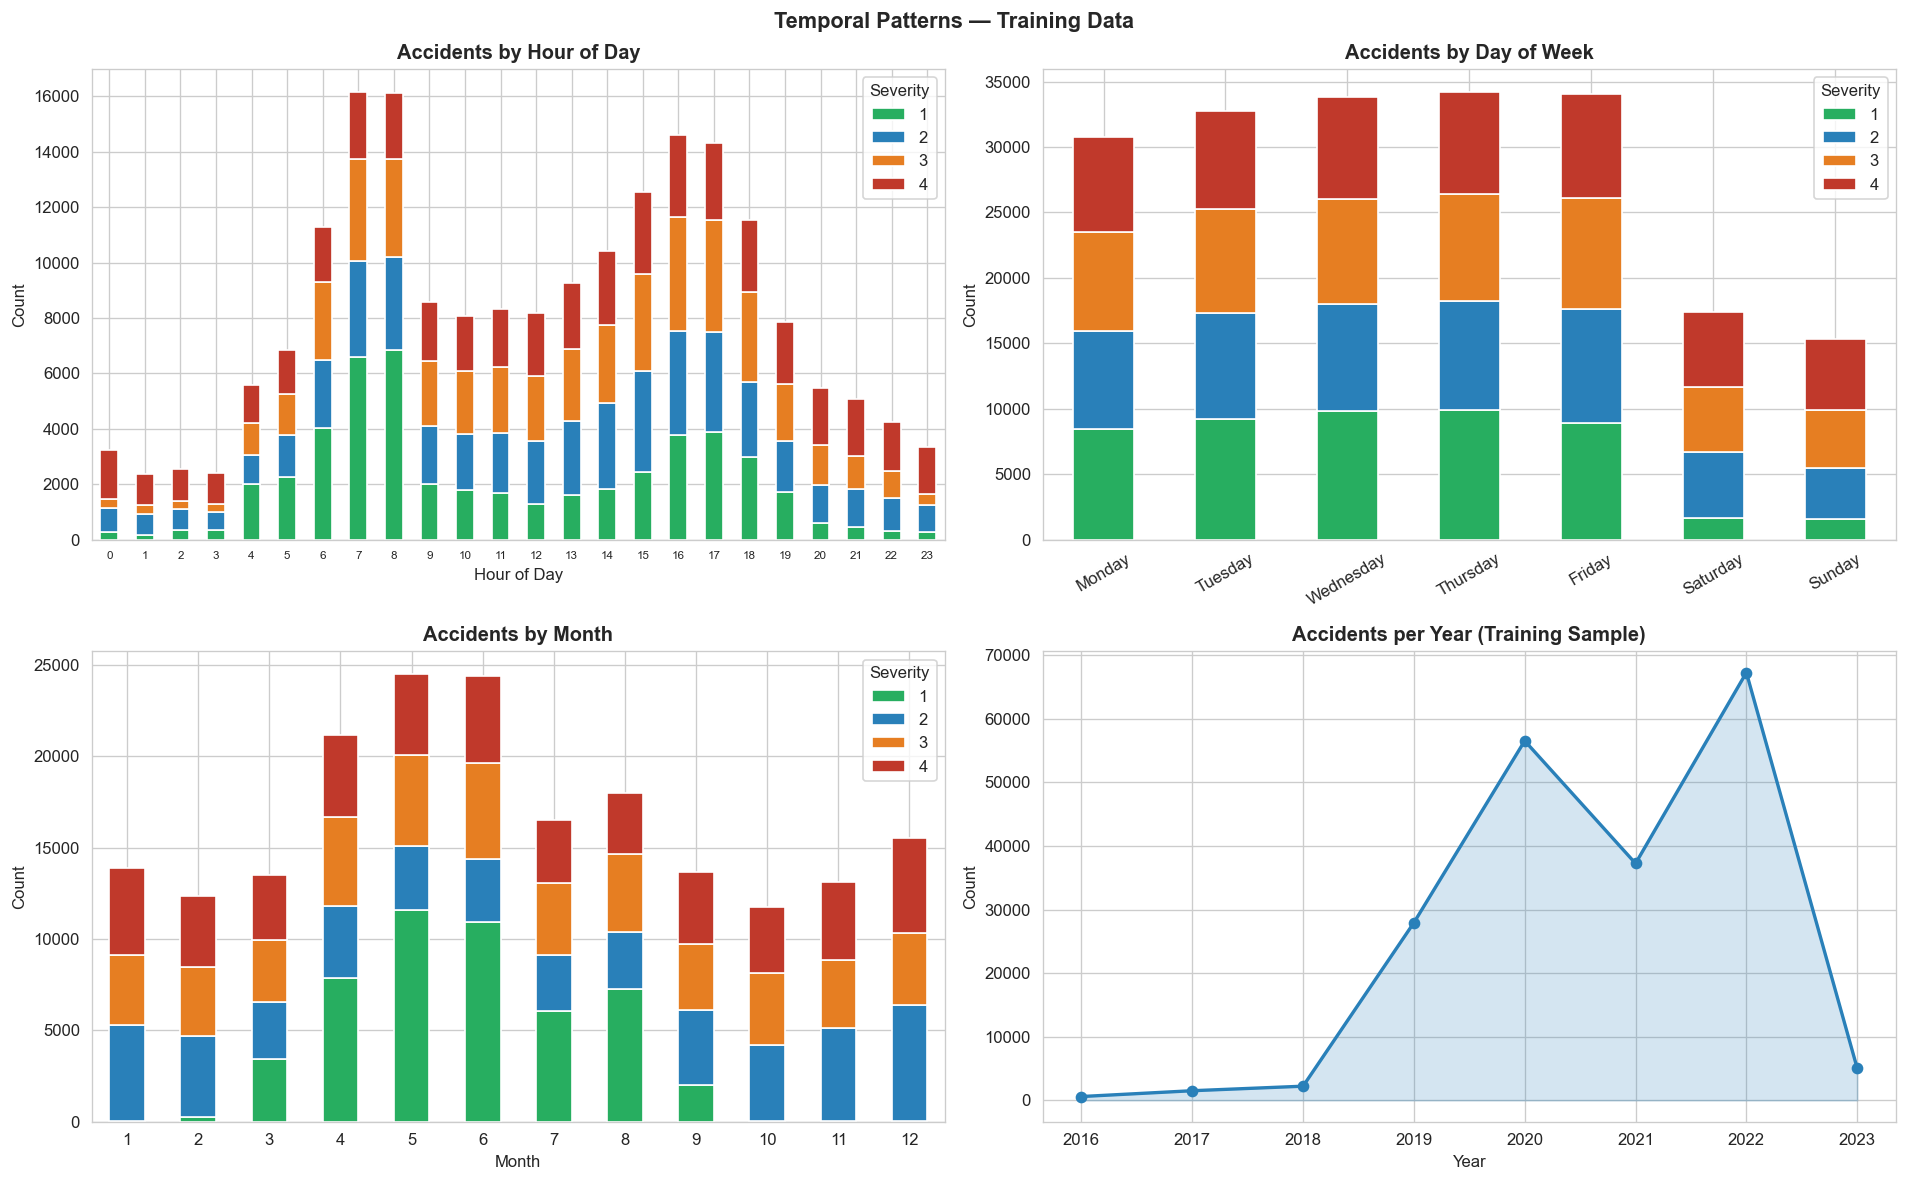

In [20]:
# 2.8 temporal patterns — when do accidents happen?
# we extract hour, day of week, and month from Start_Time

# parse the datetime column
df_train['Start_Time_dt'] = pd.to_datetime(df_train['Start_Time'], format='mixed', errors='coerce')

# extract the time components
df_train['Hour'] = df_train['Start_Time_dt'].dt.hour
df_train['DayOfWeek'] = df_train['Start_Time_dt'].dt.dayofweek  # 0 = Monday
df_train['Month'] = df_train['Start_Time_dt'].dt.month
df_train['Year'] = df_train['Start_Time_dt'].dt.year

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# top left: accidents by hour
hour_sev = df_train.groupby(['Hour', 'Severity']).size().unstack(fill_value=0)
hour_sev.plot(kind='bar', ax=axes[0, 0], color=colors_sev, edgecolor='white', stacked=True)
axes[0, 0].set_title('Accidents by Hour of Day', fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0, labelsize=7)

# top right: by day of week
dow_sev = df_train.groupby(['DayOfWeek', 'Severity']).size().unstack(fill_value=0)
dow_sev.index = day_names
dow_sev.plot(kind='bar', ax=axes[0, 1], color=colors_sev, edgecolor='white', stacked=True)
axes[0, 1].set_title('Accidents by Day of Week', fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=30)

# bottom left: by month
month_sev = df_train.groupby(['Month', 'Severity']).size().unstack(fill_value=0)
month_sev.plot(kind='bar', ax=axes[1, 0], color=colors_sev, edgecolor='white', stacked=True)
axes[1, 0].set_title('Accidents by Month', fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=0)

# bottom right: by year (just a line plot to show trends)
year_counts = df_train.groupby('Year').size()
axes[1, 1].plot(year_counts.index, year_counts.values, 'o-', color='#2980b9', lw=2)
axes[1, 1].fill_between(year_counts.index, year_counts.values, alpha=0.2, color='#2980b9')
axes[1, 1].set_title('Accidents per Year (Training Sample)', fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Count')

plt.suptitle('Temporal Patterns — Training Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02_temporal.png', bbox_inches='tight')
plt.show()


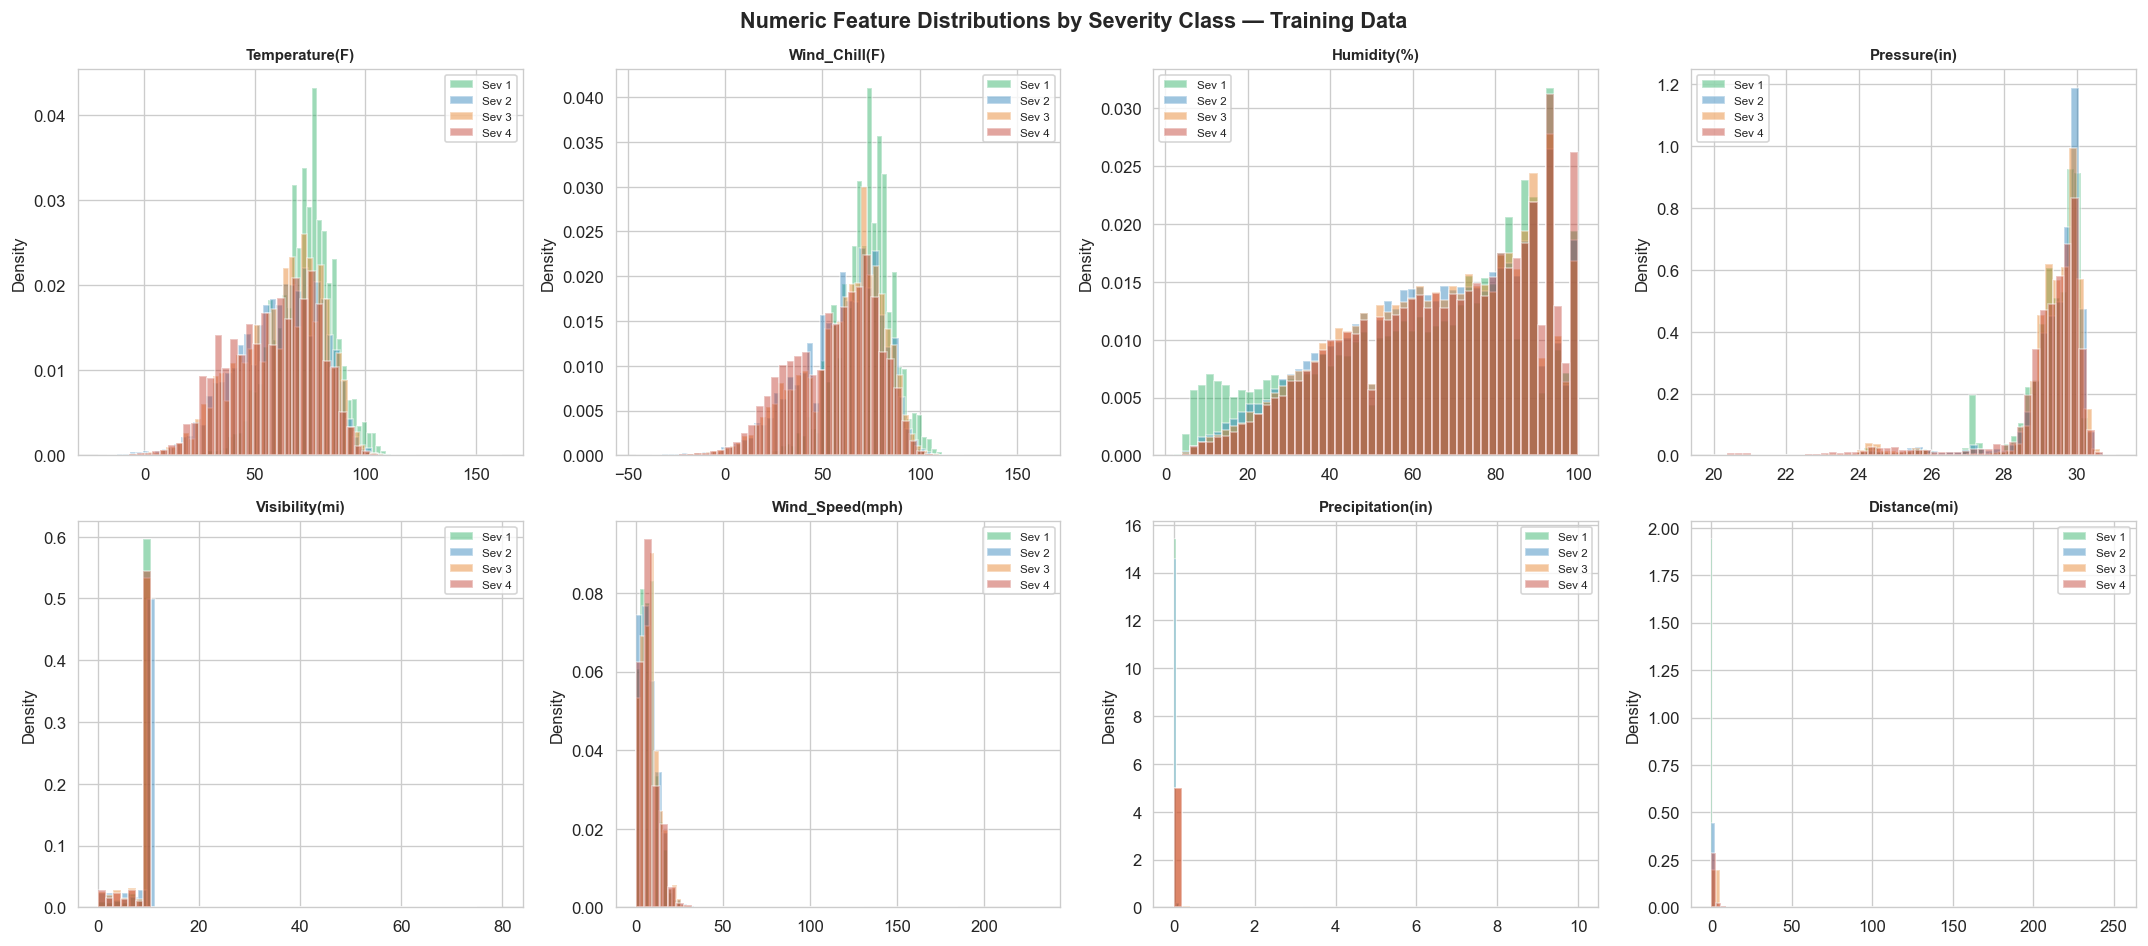

In [21]:
# 2.9 distributions of the numeric features
# we make a histogram for each numeric column, split by severity level

num_feats = [
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)'
]

# only keep the features that actually exist in the dataframe
num_feats = [f for f in num_feats if f in df_train.columns]

sev_colors = {
    1: '#27ae60',
    2: '#2980b9',
    3: '#e67e22',
    4: '#c0392b'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()  # makes it easier to loop through

for i, feat in enumerate(num_feats):
    for severity_level in sorted(df_train['Severity'].unique()):
        # get the values for this severity level
        vals = df_train[df_train['Severity'] == severity_level][feat].dropna()
        axes[i].hist(
            vals,
            bins=50,
            alpha=0.45,
            color=sev_colors[severity_level],
            density=True,
            label='Sev ' + str(severity_level)
        )
    axes[i].set_title(feat, fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)

plt.suptitle('Numeric Feature Distributions by Severity Class — Training Data',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_distributions.png', bbox_inches='tight')
plt.show()


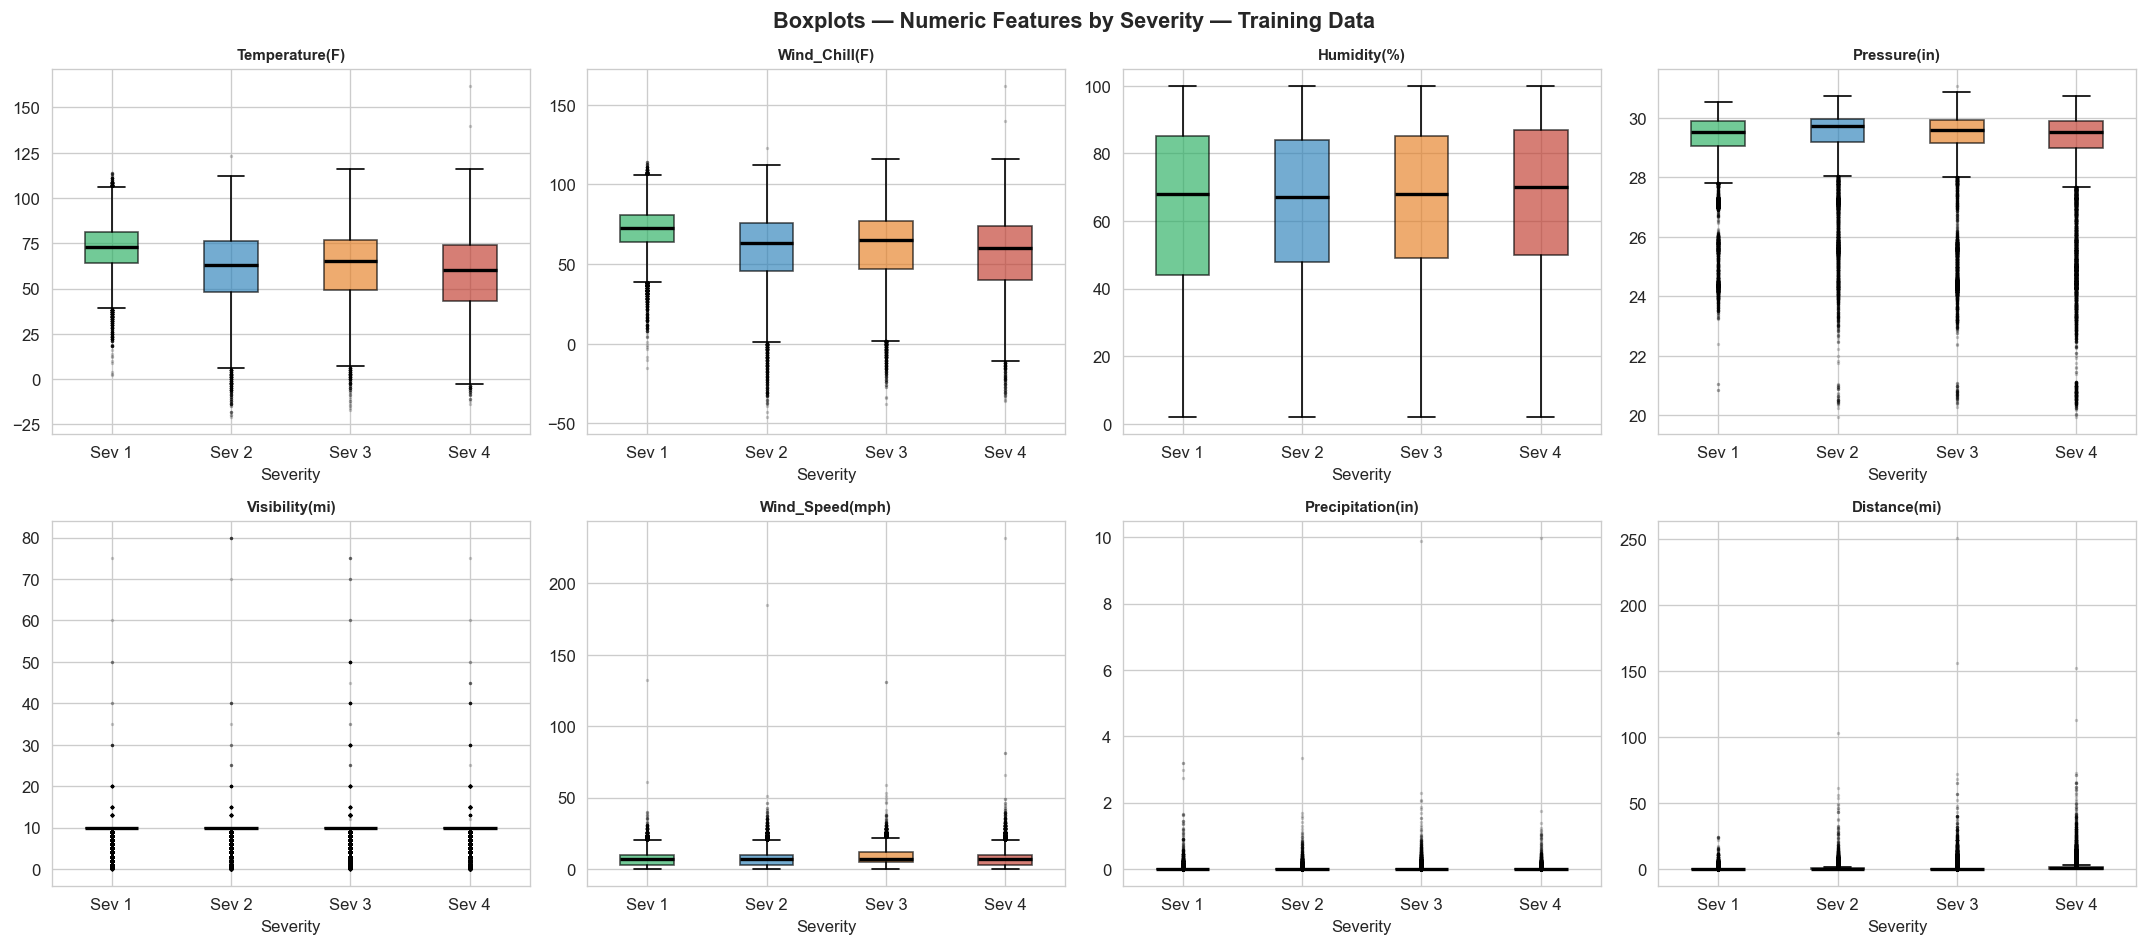

In [22]:
# 2.10 boxplots for numeric features by severity
# boxplots show the median and spread more clearly than histograms

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

severity_levels = sorted(df_train['Severity'].unique())

for i, feat in enumerate(num_feats):
    # make a list of arrays, one per severity level
    data_by_severity = []
    for s in severity_levels:
        vals = df_train[df_train['Severity'] == s][feat].dropna().values
        data_by_severity.append(vals)

    bp = axes[i].boxplot(
        data_by_severity,
        labels=['Sev ' + str(s) for s in severity_levels],
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 2},
        flierprops={'markersize': 1, 'alpha': 0.2}
    )

    # color each box differently
    box_colors = ['#27ae60', '#2980b9', '#e67e22', '#c0392b']
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    axes[i].set_title(feat, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Severity')

plt.suptitle('Boxplots — Numeric Features by Severity — Training Data',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_boxplots.png', bbox_inches='tight')
plt.show()


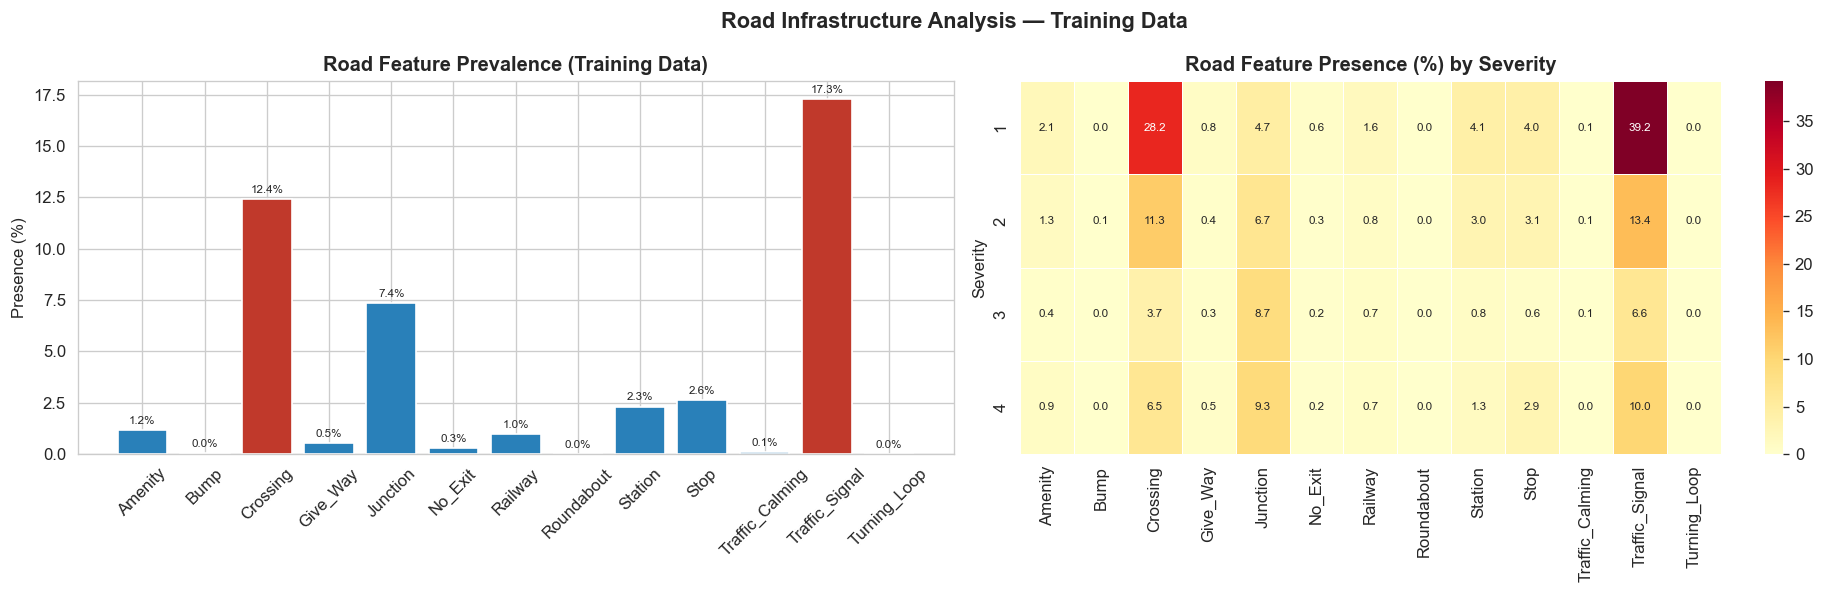

In [23]:
# 2.11 road infrastructure features
# these are boolean columns (True/False) that indicate what was near the accident

road_feats = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
]

# only keep ones that are in the dataframe
road_feats = [f for f in road_feats if f in df_train.columns]

# convert True/False to 1/0 so we can calculate percentages
# some columns might have strings 'True'/'False' instead of actual booleans
bool_map = {True: 1, False: 0, 'True': 1, 'False': 0}

road_pct = []
for feat in road_feats:
    converted = df_train[feat].map(bool_map)
    avg = converted.mean() * 100
    road_pct.append(avg)

road_pct = pd.Series(road_pct, index=road_feats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# bar chart: how common is each road feature?
bar_colors = ['#c0392b' if v > 10 else '#2980b9' for v in road_pct.values]
axes[0].bar(road_pct.index, road_pct.values, color=bar_colors, edgecolor='white')
axes[0].set_ylabel('Presence (%)')
axes[0].set_title('Road Feature Prevalence (Training Data)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(road_pct.values):
    axes[0].text(i, v + 0.3, str(round(v, 1)) + '%', ha='center', fontsize=7)

# heatmap: how does each feature vary by severity?
road_by_sev = pd.DataFrame()
for feat in road_feats:
    converted = df_train[feat].map(bool_map)
    by_sev = df_train.groupby('Severity').apply(lambda g: converted.loc[g.index].mean() * 100)
    road_by_sev[feat] = by_sev

sns.heatmap(
    road_by_sev,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    ax=axes[1],
    linewidths=0.5,
    annot_kws={'size': 7}
)
axes[1].set_title('Road Feature Presence (%) by Severity', fontweight='bold')

plt.suptitle('Road Infrastructure Analysis — Training Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_road_features.png', bbox_inches='tight')
plt.show()


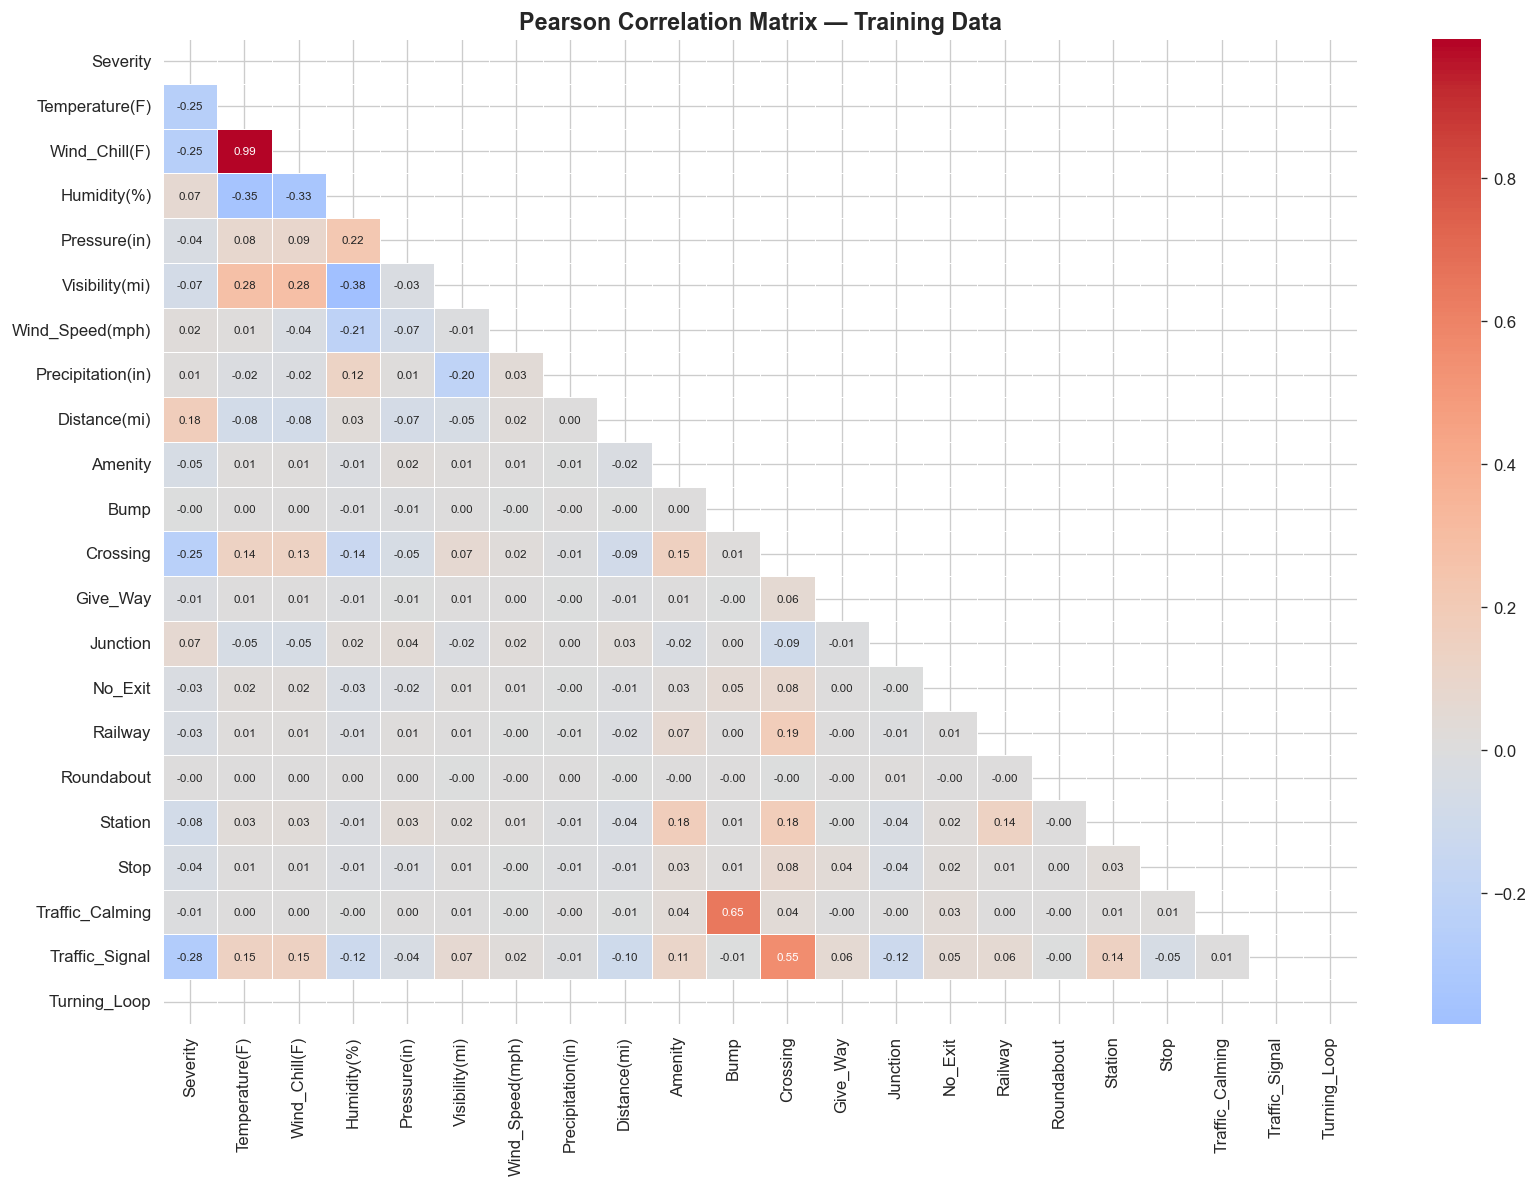

  Traffic_Signal: -0.2793
  Wind_Chill(F): -0.2505
  Temperature(F): -0.2498
  Crossing: -0.2470
  Distance(mi): 0.1773
  Station: -0.0788
  Visibility(mi): -0.0737
  Junction: 0.0683
  Humidity(%): 0.0683
  Amenity: -0.0451


In [24]:
# 2.12 correlation matrix
# this shows us how much each feature is linearly related to every other feature
# we're mostly interested in which features correlate with Severity

# build a dataframe with just the numeric and road features
corr_cols = ['Severity'] + num_feats
corr_df = df_train[corr_cols].copy()

# add the road features (convert bool to int first)
bool_map = {True: 1, False: 0, 'True': 1, 'False': 0}
for feat in road_feats:
    corr_df[feat] = df_train[feat].map(bool_map)

corr_matrix = corr_df.corr()

# only show the lower triangle (upper half is a mirror image)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.3,
    annot_kws={'size': 7}
)
ax.set_title('Pearson Correlation Matrix — Training Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_06_correlation.png', bbox_inches='tight')
plt.show()

# print the top 10 features most correlated with Severity
sev_corr = corr_matrix['Severity'].drop('Severity').abs().sort_values(ascending=False)
for feat, val in sev_corr.head(10).items():
    actual_corr = corr_matrix['Severity'][feat]
    print(f'  {feat}: {actual_corr:.4f}')


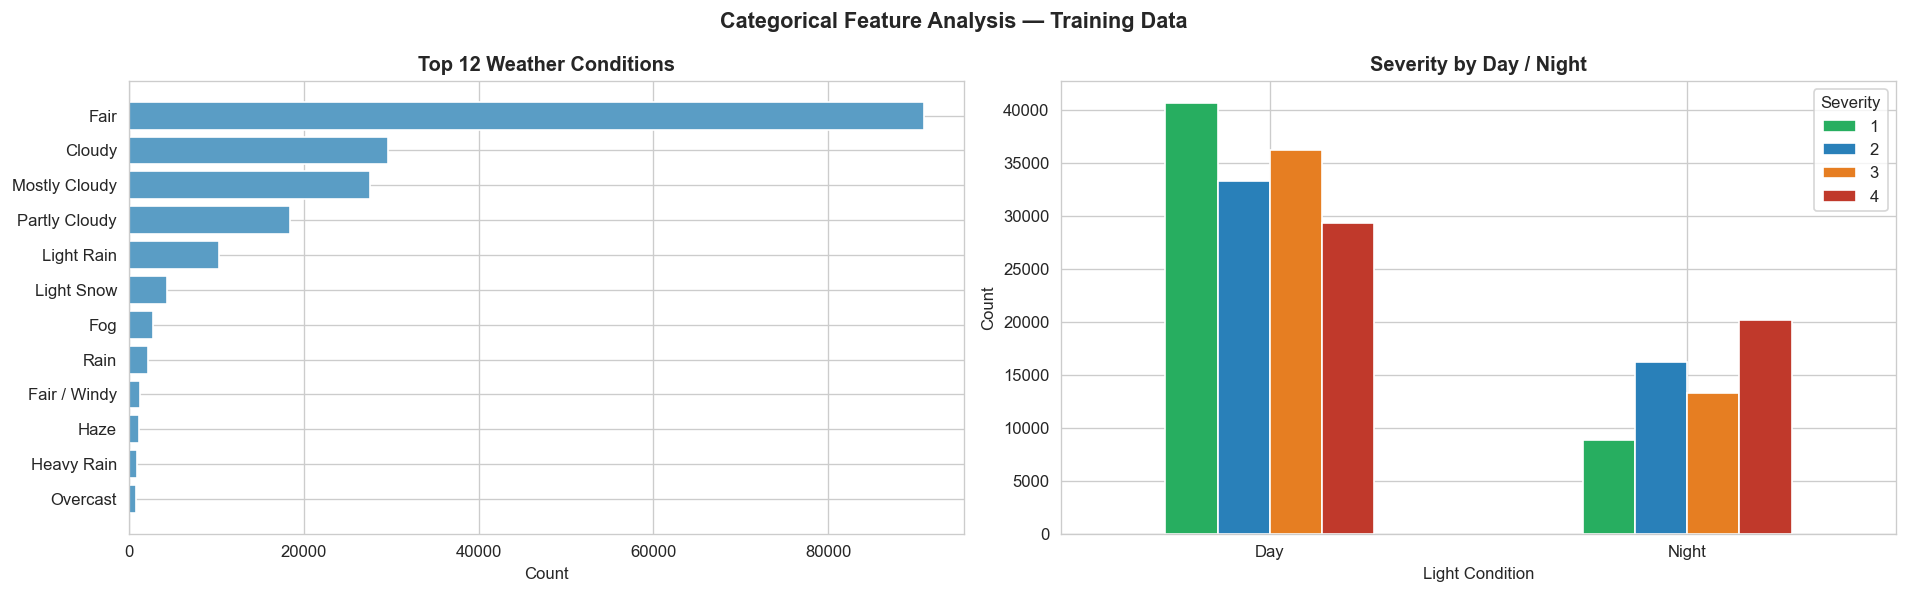

In [25]:
# 2.13 weather and day/night analysis

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: what are the most common weather conditions?
top_weather = df_train['Weather_Condition'].value_counts().head(12)
axes[0].barh(top_weather.index[::-1], top_weather.values[::-1], color='#5a9dc5')
axes[0].set_title('Top 12 Weather Conditions', fontweight='bold')
axes[0].set_xlabel('Count')

# right: does severity differ between day and night?
day_night_sev = df_train.groupby(['Sunrise_Sunset', 'Severity']).size().unstack(fill_value=0)
colors_sev = ['#27ae60', '#2980b9', '#e67e22', '#c0392b']
day_night_sev.plot(kind='bar', ax=axes[1], color=colors_sev, edgecolor='white')
axes[1].set_title('Severity by Day / Night', fontweight='bold')
axes[1].set_xlabel('Light Condition')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Severity')

plt.suptitle('Categorical Feature Analysis — Training Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_categorical.png', bbox_inches='tight')
plt.show()


## EDA Summary
Training rows: 198400
Columns: 38
Missing values: 0

Key observations:
1. Most accidents happen during rush hours (7-9am and 4-6pm)
   but high severity accidents are more spread out through the day
2. Temperature and wind chill have a negative correlation with severity
   meaning colder conditions are linked to more severe accidents
3. Traffic signals and crossings are more common for low severity accidents
4. Distance (road impact zone) is one of the strongest predictors
5. Night time accidents tend to be more severe than daytime ones
6. Most accidents happen in fair weather - severity is not just about bad weather

---
## 3. Preprocessing

Before we can feed data into a machine learning model, we need to:
1. Create the binary target column (Low=0, High=1)
2. Engineer some new features (duration, rush hour flag, etc.)
3. Handle the cardinality of weather conditions
4. Scale numeric features and encode categorical ones

**Important:** All preprocessing is fitted only on the training data.  
We then apply those fitted transformers to the test data.  
This prevents leakage.


In [26]:
# 3.1 feature engineering
# we create some new features that might help the model
# we put this in a function so we can apply it the same way to both train and test

def make_new_features(df):
    # work on a copy so we don't change the original
    df = df.copy()

    # parse the datetime columns
    start = pd.to_datetime(df['Start_Time'], format='mixed', errors='coerce')
    end = pd.to_datetime(df['End_Time'], format='mixed', errors='coerce')

    # how long did the accident last? (in minutes)
    # we cap it at 24 hours to remove obvious data errors
    df['Duration_min'] = (end - start).dt.total_seconds() / 60
    df['Duration_min'] = df['Duration_min'].clip(0, 1440)

    # time-based features
    df['Hour'] = start.dt.hour
    df['DayOfWeek'] = start.dt.dayofweek  # 0 = Monday, 6 = Sunday
    df['Month'] = start.dt.month

    # was it a weekend?
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

    # was it rush hour? (morning rush 7-9am, evening rush 4-6pm)
    rush_hours = [7, 8, 9, 16, 17, 18]
    df['IsRushHour'] = df['Hour'].isin(rush_hours).astype(int)

    # was it night time?
    df['IsNight'] = df['Sunrise_Sunset'].map({'Night': 1, 'Day': 0}).fillna(0).astype(int)

    # convert the True/False road flag columns to 0/1 integers
    bool_cols = [
        'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
        'Railway', 'Roundabout', 'Station', 'Stop',
        'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
    ]
    bool_map = {True: 1, False: 0, 'True': 1, 'False': 0}

    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].map(bool_map).fillna(0).astype(int)

    return df


# apply to both splits
df_train = make_new_features(df_train)
df_test = make_new_features(df_test)

print('New features created for train and test sets.')
print('New columns:', ['Duration_min', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsRushHour', 'IsNight'])


New features created for train and test sets.
New columns: ['Duration_min', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsRushHour', 'IsNight']


In [27]:
# 3.2 create the binary target column
# create binary target
df_train['Target'] = (df_train['Severity'] >= 3).astype(int)
df_test['Target'] = (df_test['Severity'] >= 3).astype(int)

# check distribution in train
low_train = (df_train['Target'] == 0).sum()
high_train = (df_train['Target'] == 1).sum()

print("Train:")
print("Low =", low_train)
print("High =", high_train)

# check distribution in test
low_test = (df_test['Target'] == 0).sum()
high_test = (df_test['Target'] == 1).sum()

print("\nTest:")
print("Low =", low_test)
print("High =", high_test)

Train:
Low = 99200
High = 99200

Test:
Low = 24800
High = 24800


In [28]:
# 3.3 define the feature groups
# we need to tell sklearn which columns are numeric, which are categorical, etc.

# define feature groups
NUMERIC_FEATURES = [
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)',
    'Hour', 'DayOfWeek', 'Month', 'Duration_min'
]

CATEGORICAL_FEATURES = [
    'Weather_Condition', 'Wind_Direction', 'Sunrise_Sunset'
]

BINARY_FEATURES = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
    'IsWeekend', 'IsRushHour', 'IsNight'
]

# keep only features that exist in the dataframe
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in df_train.columns]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in df_train.columns]
BINARY_FEATURES = [f for f in BINARY_FEATURES if f in df_train.columns]

# combine all features
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

# print information
print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print("Binary features:", BINARY_FEATURES)
print("Total features:", len(ALL_FEATURES))

Numeric features: ['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)', 'Hour', 'DayOfWeek', 'Month', 'Duration_min']
Categorical features: ['Weather_Condition', 'Wind_Direction', 'Sunrise_Sunset']
Binary features: ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'IsWeekend', 'IsRushHour', 'IsNight']
Total features: 31


In [29]:
# 3.4 reduce weather condition cardinality
# there are hundreds of different weather conditions, which would create too many columns
# we keep only the top 20 most common ones, and call everything else 'Other'
# IMPORTANT: we figure out the top 20 from TRAINING data only!

# get the top 20 weather conditions from training data
top_20_weather = df_train['Weather_Condition'].value_counts().head(20).index.tolist()
print('Top 20 weather conditions:', top_20_weather)

# replace rare weather conditions with 'Other'
df_train['Weather_Condition'] = df_train['Weather_Condition'].where(
    df_train['Weather_Condition'].isin(top_20_weather), other='Other'
)
df_test['Weather_Condition'] = df_test['Weather_Condition'].where(
    df_test['Weather_Condition'].isin(top_20_weather), other='Other'
)

# now separate features (X) from labels (y)
X_train = df_train[ALL_FEATURES]
y_train = df_train['Target']

X_test = df_test[ALL_FEATURES]
y_test = df_test['Target']

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


Top 20 weather conditions: ['Fair', 'Cloudy', 'Mostly Cloudy', 'Partly Cloudy', 'Light Rain', 'Light Snow', 'Fog', 'Rain', 'Fair / Windy', 'Haze', 'Heavy Rain', 'Overcast', 'T-Storm', 'Light Drizzle', 'Mostly Cloudy / Windy', 'Cloudy / Windy', 'Thunder in the Vicinity', 'Light Rain with Thunder', 'Snow', 'Thunder']
X_train shape: (198400, 31)
X_test shape: (49600, 31)


In [30]:
# 3.5 build the preprocessing pipeline
# we use sklearn's Pipeline and ColumnTransformer for this
#
# for numeric features:
#   - fill missing values with the median
#   - scale to have mean=0 and std=1 (StandardScaler)
#
# for categorical features:
#   - fill missing values with the most common value
#   - convert to numbers using OneHotEncoding
#
# for binary features:
#   - just fill any missing values with the most common value

numeric_pipeline = Pipeline([
    ('fill_missing', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('fill_missing', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

binary_pipeline = Pipeline([
    ('fill_missing', SimpleImputer(strategy='most_frequent'))
])

# combine them all into one transformer
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, NUMERIC_FEATURES),
    ('categorical', categorical_pipeline, CATEGORICAL_FEATURES),
    ('binary', binary_pipeline, BINARY_FEATURES)
])

# fit on training data, then transform both train and test
# .fit_transform() = learn the stats AND apply them
# .transform() = just apply (using the stats learned from train)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print('X_train_prep shape:', X_train_prep.shape)
print('X_test_prep shape:', X_test_prep.shape)
print('(The number of columns went up because of one-hot encoding)')


X_train_prep shape: (198400, 74)
X_test_prep shape: (49600, 74)
(The number of columns went up because of one-hot encoding)


---
## 4. PCA - Principal Component Analysis

PCA helps us understand the structure of our feature space.  
We want to know: how many components do we need to capture most of the variance?  
And: can we see any separation between Low and High severity in 2D?


Total features after preprocessing: 74
Components needed for 95% variance: 25
Components needed for 99% variance: 40
Dimension reduction with 95%: 66.2%


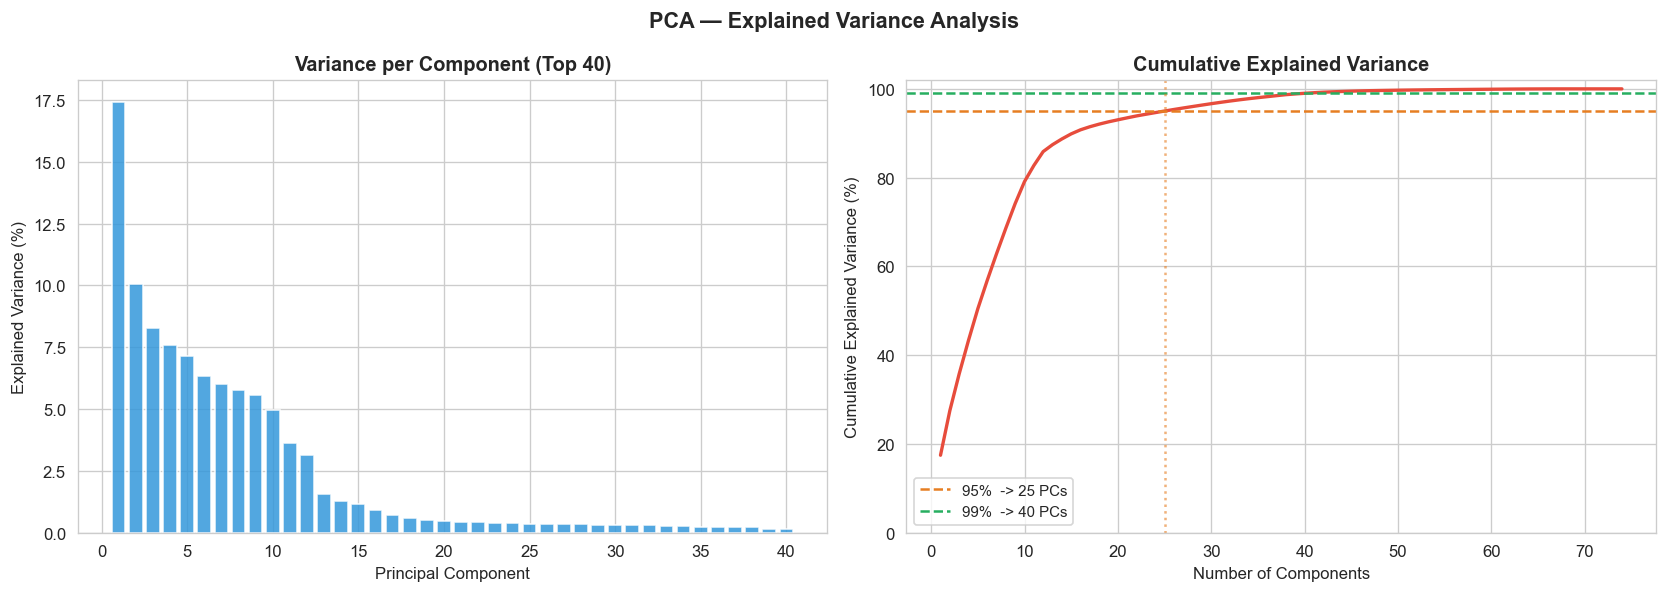

In [31]:
# 4.1 run PCA and see how many components we need
# we fit PCA on the training data

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_prep)

# cumulative explained variance
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# how many components do we need for 95% of variance?
n_for_95 = int(np.argmax(cumulative >= 0.95)) + 1
n_for_99 = int(np.argmax(cumulative >= 0.99)) + 1
total_features = X_train_prep.shape[1]

print('Total features after preprocessing:', total_features)
print('Components needed for 95% variance:', n_for_95)
print('Components needed for 99% variance:', n_for_99)
print('Dimension reduction with 95%:', str(round((1 - n_for_95/total_features)*100, 1)) + '%')

# plot it
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: variance per component (first 40)
top_n = min(40, total_features)
axes[0].bar(
    range(1, top_n + 1),
    explained[:top_n] * 100,
    color='#3498db', alpha=0.85
)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Variance per Component (Top ' + str(top_n) + ')', fontweight='bold')

# right: cumulative variance
axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, color='#e74c3c', lw=2)
axes[1].axhline(95, color='#e67e22', ls='--', lw=1.5, label='95%  -> ' + str(n_for_95) + ' PCs')
axes[1].axhline(99, color='#27ae60', ls='--', lw=1.5, label='99%  -> ' + str(n_for_99) + ' PCs')
axes[1].axvline(n_for_95, color='#e67e22', ls=':', alpha=0.6)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 102)

plt.suptitle('PCA — Explained Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_08_pca_variance.png', bbox_inches='tight')
plt.show()


In [32]:
# 4.2 build the 95% PCA (we'll use this for the 2D plot)
pca_95 = PCA(n_components=n_for_95, random_state=RANDOM_STATE)
X_train_pca = pca_95.fit_transform(X_train_prep)
X_test_pca = pca_95.transform(X_test_prep)

print('PCA-reduced training set shape:', X_train_pca.shape)
print('PCA-reduced test set shape:', X_test_pca.shape)


PCA-reduced training set shape: (198400, 25)
PCA-reduced test set shape: (49600, 25)


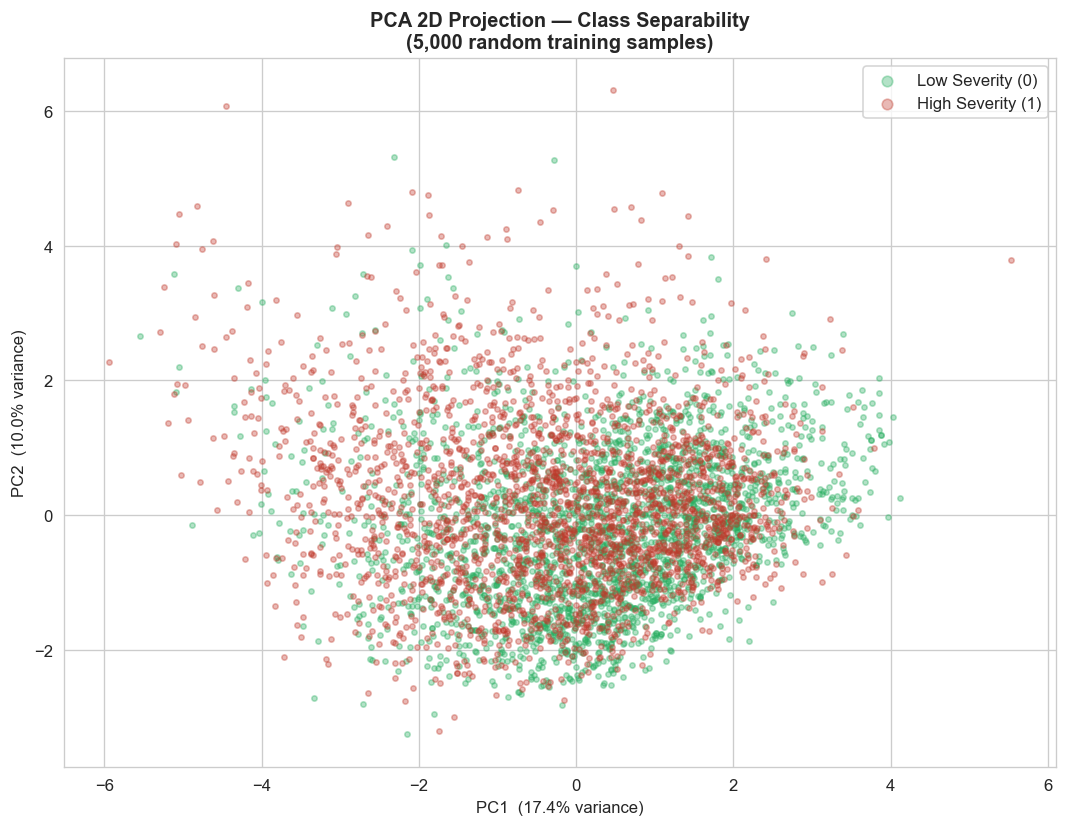

Notice: the two classes overlap a lot in 2D.
This means a simple linear model will struggle — we need non-linear models like RF and GB.


In [33]:
# 4.3 visualise the two classes in 2D (using first two principal components)
# this shows us whether Low and High severity can be separated

# use a random sample of 5000 points so the plot doesn't get too crowded
sample_size = 5000
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_train_pca), sample_size, replace=False)

X_sample = X_train_pca[sample_idx]
y_sample = y_train.values[sample_idx]

fig, ax = plt.subplots(figsize=(9, 7))

# plot Low severity (0) and High severity (1) separately
low_idx = (y_sample == 0)
high_idx = (y_sample == 1)

ax.scatter(X_sample[low_idx, 0], X_sample[low_idx, 1],
           alpha=0.35, s=10, c='#27ae60', label='Low Severity (0)')
ax.scatter(X_sample[high_idx, 0], X_sample[high_idx, 1],
           alpha=0.35, s=10, c='#c0392b', label='High Severity (1)')

pc1_var = round(pca_full.explained_variance_ratio_[0] * 100, 1)
pc2_var = round(pca_full.explained_variance_ratio_[1] * 100, 1)

ax.set_xlabel('PC1  (' + str(pc1_var) + '% variance)')
ax.set_ylabel('PC2  (' + str(pc2_var) + '% variance)')
ax.set_title('PCA 2D Projection — Class Separability\n(5,000 random training samples)',
             fontweight='bold')
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig('fig_09_pca_2d.png', bbox_inches='tight')
plt.show()

print('Notice: the two classes overlap a lot in 2D.')
print('This means a simple linear model will struggle — we need non-linear models like RF and GB.')


---
## 5. Baseline Models

Before trying our main models we train some simple baselines.  
This gives us a floor to compare against.  
If our fancy models don't beat the baselines, something is wrong.


In [34]:
# helper function to evaluate any model and return its scores
# we'll reuse this function for every model in the notebook

def evaluate_model(model_name, model, X_test_data, y_test_data, train_time=0):
    # make predictions
    y_pred = model.predict(X_test_data)

    # get probability scores if the model supports it
    # some models like Hard Voting don't have predict_proba
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_data)[:, 1]
        auc = roc_auc_score(y_test_data, y_proba)
    else:
        # use predictions as a substitute (won't be as good)
        y_proba = y_pred.astype(float)
        auc = roc_auc_score(y_test_data, y_proba)

    # calculate all the metrics
    acc = accuracy_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred, average='weighted')
    prec = precision_score(y_test_data, y_pred, average='weighted')
    rec = recall_score(y_test_data, y_pred, average='weighted')
    cm = confusion_matrix(y_test_data, y_pred)

    # print a summary
    print(model_name)
    print('  Accuracy :', round(acc, 4))
    print('  F1 Score :', round(f1, 4))
    print('  ROC-AUC  :', round(auc, 4))
    print('  Time     :', round(train_time, 1), 's')
    print()

    # return everything in a dictionary
    return {
        'name': model_name,
        'Accuracy': acc,
        'F1_Weighted': f1,
        'Precision': prec,
        'Recall': rec,
        'ROC_AUC': auc,
        'Train_Time': train_time,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'CM': cm
    }


In [35]:
# train and test the baseline models
# we store all results in a dictionary so we can compare them later

baseline_results = {}

# Baseline 1: Naive Bayes (very simple probabilistic model)
# it works on the PCA-reduced data because it assumes features are independent
nb_model = GaussianNB()
t0 = time.time()
nb_model.fit(X_train_pca, y_train)  # uses PCA data
t1 = time.time() - t0
baseline_results['Naive Bayes'] = evaluate_model('Naive Bayes', nb_model, X_test_pca, y_test, t1)

# Baseline 2: Logistic Regression
# a linear model, works on the full preprocessed data
lr_model = LogisticRegression(
    C=1.0,
    max_iter=500,
    solver='lbfgs',
    class_weight='balanced',
    random_state=RANDOM_STATE
)
t0 = time.time()
lr_model.fit(X_train_prep, y_train)
t1 = time.time() - t0
baseline_results['Logistic Regression'] = evaluate_model('Logistic Regression', lr_model, X_test_prep, y_test, t1)

# Baseline 3: Decision Tree
# a single tree (not an ensemble), good baseline for comparison with RF
dt_model = DecisionTreeClassifier(
    max_depth=8,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
t0 = time.time()
dt_model.fit(X_train_prep, y_train)
t1 = time.time() - t0
baseline_results['Decision Tree'] = evaluate_model('Decision Tree', dt_model, X_test_prep, y_test, t1)


Naive Bayes
  Accuracy : 0.6121
  F1 Score : 0.6058
  ROC-AUC  : 0.6802
  Time     : 0.1 s

Logistic Regression
  Accuracy : 0.6564
  F1 Score : 0.6562
  ROC-AUC  : 0.7101
  Time     : 1.2 s

Decision Tree
  Accuracy : 0.6921
  F1 Score : 0.6873
  ROC-AUC  : 0.7635
  Time     : 1.4 s



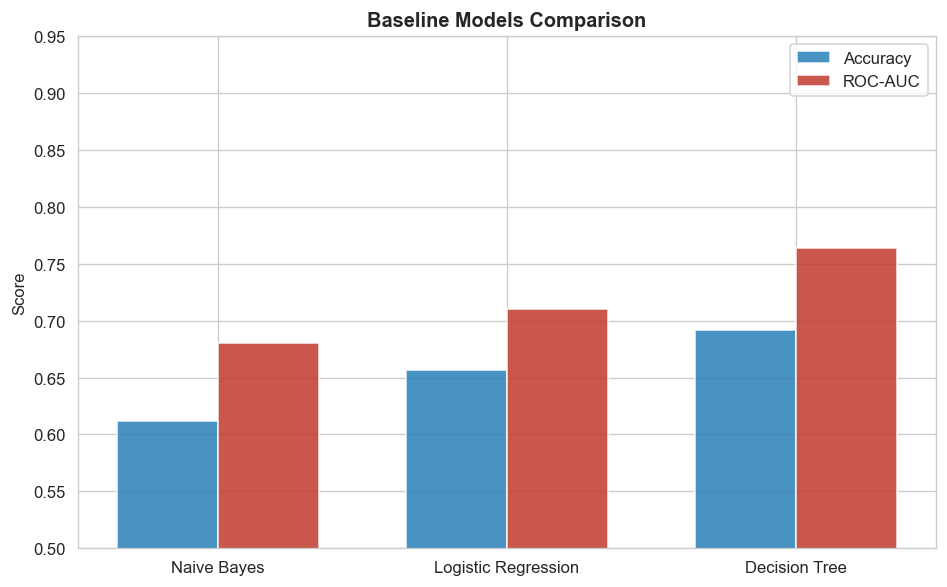

In [36]:
# plot a comparison bar chart for the baselines
baseline_names = list(baseline_results.keys())
baseline_acc = [baseline_results[m]['Accuracy'] for m in baseline_names]
baseline_auc = [baseline_results[m]['ROC_AUC'] for m in baseline_names]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(baseline_names))
width = 0.35

ax.bar(x - width/2, baseline_acc, width, label='Accuracy', color='#2980b9', alpha=0.85)
ax.bar(x + width/2, baseline_auc, width, label='ROC-AUC', color='#c0392b', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(baseline_names)
ax.set_ylim(0.5, 0.95)
ax.set_ylabel('Score')
ax.set_title('Baseline Models Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## 6. Random Forest

Random Forest is an ensemble of decision trees.  
Each tree is trained on a random subset of the data and features.  
The final prediction is the majority vote across all trees.  

One nice thing about Random Forest is the OOB score (Out-of-Bag score).  
Each tree is trained on a bootstrap sample (~63% of data), and the remaining ~37%  
is used to validate that tree. The OOB score averages this across all trees — it's  
basically a free validation score that closely tracks test accuracy.


In [37]:
# 6.1 train the main Random Forest model
# these hyperparameters were chosen based on the sensitivity analysis below

rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_split=30, min_samples_leaf=10, max_features='sqrt',
                                  class_weight='balanced_subsample', oob_score=True, n_jobs=-1, random_state=RANDOM_STATE)

t0 = time.time()
rf_model.fit(X_train_prep, y_train)
rf_time = time.time() - t0

rf_res = evaluate_model('Random Forest', rf_model, X_test_prep, y_test, rf_time)

# oob_score_ is a special attribute only available after training with oob_score=True
print('OOB Score (free internal validation):', round(rf_model.oob_score_, 4))
print('Test Accuracy:', round(rf_res['Accuracy'], 4))
print('(OOB and test accuracy should be close if the model is not overfitting)')


Random Forest
  Accuracy : 0.7173
  F1 Score : 0.7136
  ROC-AUC  : 0.7949
  Time     : 5.0 s

OOB Score (free internal validation): 0.7133
Test Accuracy: 0.7173
(OOB and test accuracy should be close if the model is not overfitting)


# 6.2 sensitivity analysis: how many trees do we actually need?
# we test different values of n_estimators and track accuracy and OOB score

print('Testing different numbers of trees...')

tree_counts = [10, 20, 30, 50, 75, 100, 125, 150]
acc_scores = []
auc_scores = []
oob_scores = []

for n_trees in tree_counts:
    model = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_prep, y_train)

    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]

    acc_scores.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    oob_scores.append(model.oob_score_)

    print('  n_estimators =', n_trees,
          ' Acc =', round(acc_scores[-1], 4),
          ' AUC =', round(auc_scores[-1], 4),
          ' OOB =', round(oob_scores[-1], 4))

# plot the results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(tree_counts, acc_scores, 'o-', color='#2980b9', lw=2, label='Test Accuracy')
axes[0].plot(tree_counts, oob_scores, 's--', color='#e67e22', lw=2, label='OOB Score')
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Score')
axes[0].set_title('RF — Accuracy & OOB vs n_estimators', fontweight='bold')
axes[0].legend()

axes[1].plot(tree_counts, auc_scores, 'o-', color='#c0392b', lw=2)
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('RF — ROC-AUC vs n_estimators', fontweight='bold')

plt.suptitle('Random Forest — n_estimators Sensitivity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_10_rf_n_estimators.png', bbox_inches='tight')
plt.show()


In [38]:
# 6.2 sensitivity analysis: how many trees do we actually need?
# we test different values of n_estimators and track accuracy and OOB score

print('Testing different numbers of trees...')

tree_counts = [10, 20, 30, 50, 75, 100, 125, 150]

acc_scores = []
auc_scores = []
oob_scores = []

for n_trees in tree_counts:

    model = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_prep, y_train)

    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    oob = model.oob_score_

    acc_scores.append(acc)
    auc_scores.append(auc)
    oob_scores.append(oob)

    print('n_estimators =', n_trees,
          'Acc =', round(acc,4),
          'AUC =', round(auc,4),
          'OOB =', round(oob,4))

Testing different numbers of trees...
n_estimators = 10 Acc = 0.7153 AUC = 0.7892 OOB = 0.6973
n_estimators = 20 Acc = 0.7178 AUC = 0.7923 OOB = 0.7077
n_estimators = 30 Acc = 0.7175 AUC = 0.7916 OOB = 0.7093
n_estimators = 50 Acc = 0.7198 AUC = 0.7946 OOB = 0.7133
n_estimators = 75 Acc = 0.7174 AUC = 0.7935 OOB = 0.7123
n_estimators = 100 Acc = 0.7177 AUC = 0.7942 OOB = 0.7133
n_estimators = 125 Acc = 0.7186 AUC = 0.7951 OOB = 0.7148
n_estimators = 150 Acc = 0.7186 AUC = 0.7955 OOB = 0.7151


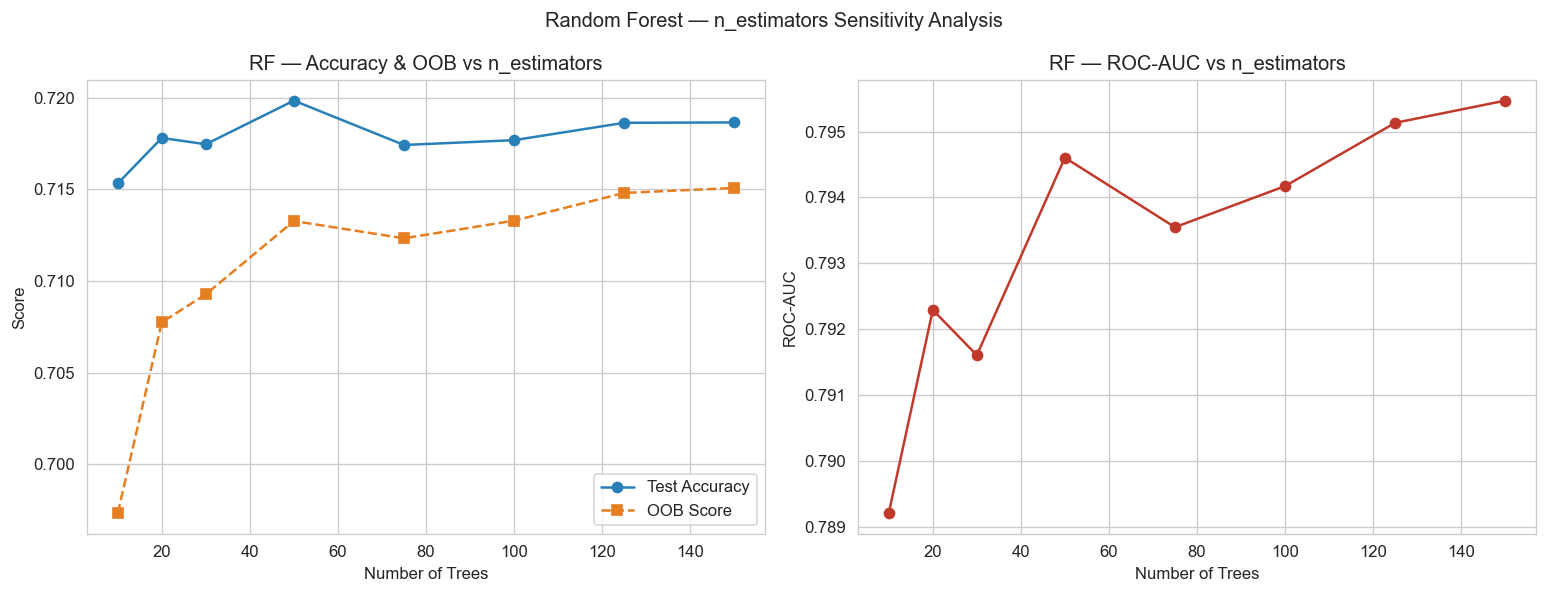

In [39]:
# -------- Plot results --------

fig, axes = plt.subplots(1,2, figsize=(13,5))

axes[0].plot(tree_counts, acc_scores, 'o-', color='#2980b9', label='Test Accuracy')
axes[0].plot(tree_counts, oob_scores, 's--', color='#e67e22', label='OOB Score')
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Score')
axes[0].set_title('RF — Accuracy & OOB vs n_estimators')
axes[0].legend()

axes[1].plot(tree_counts, auc_scores, 'o-', color='#c0392b')
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('RF — ROC-AUC vs n_estimators')

plt.suptitle('Random Forest — n_estimators Sensitivity Analysis')

plt.tight_layout()
plt.show()

In [40]:
# 6.3 sensitivity analysis: what is the best max_depth?
# deeper trees can capture more patterns but might overfit
# None means unlimited depth

print('Testing different tree depths...')

depths_to_try = [3, 5, 7, 9, 12, 15, 20, None]
depth_acc = []
depth_auc = []

for depth in depths_to_try:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_prep, y_train)

    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]

    depth_acc.append(accuracy_score(y_test, y_pred))
    depth_auc.append(roc_auc_score(y_test, y_proba))

    print('  depth =', str(depth), ' Acc =', round(depth_acc[-1], 4), ' AUC =', round(depth_auc[-1], 4))



Testing different tree depths...
  depth = 3  Acc = 0.6676  AUC = 0.7209
  depth = 5  Acc = 0.6821  AUC = 0.7429
  depth = 7  Acc = 0.6971  AUC = 0.7596
  depth = 9  Acc = 0.7052  AUC = 0.7736
  depth = 12  Acc = 0.7177  AUC = 0.7942
  depth = 15  Acc = 0.7265  AUC = 0.8066
  depth = 20  Acc = 0.7385  AUC = 0.8223
  depth = None  Acc = 0.7464  AUC = 0.8307


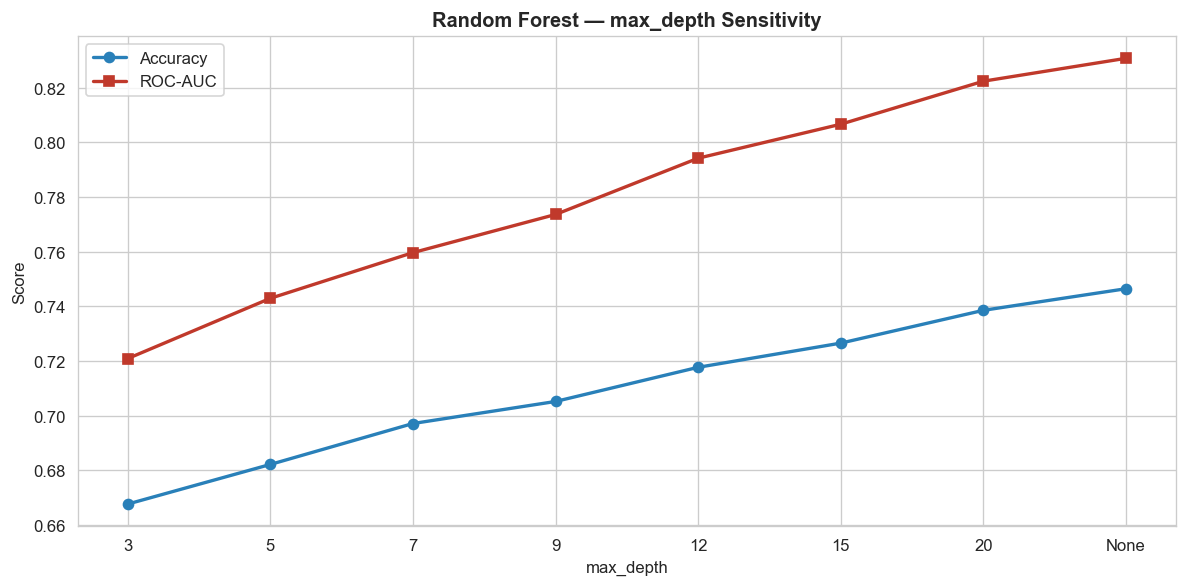

In [41]:
# use strings for the x-axis labels (None won't plot otherwise)
depth_labels = [str(d) if d is not None else 'None' for d in depths_to_try]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depth_labels, depth_acc, 'o-', color='#2980b9', lw=2, label='Accuracy')
ax.plot(depth_labels, depth_auc, 's-', color='#c0392b', lw=2, label='ROC-AUC')
ax.set_xlabel('max_depth')
ax.set_ylabel('Score')
ax.set_title('Random Forest — max_depth Sensitivity', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_11_rf_depth.png', bbox_inches='tight')
plt.show()


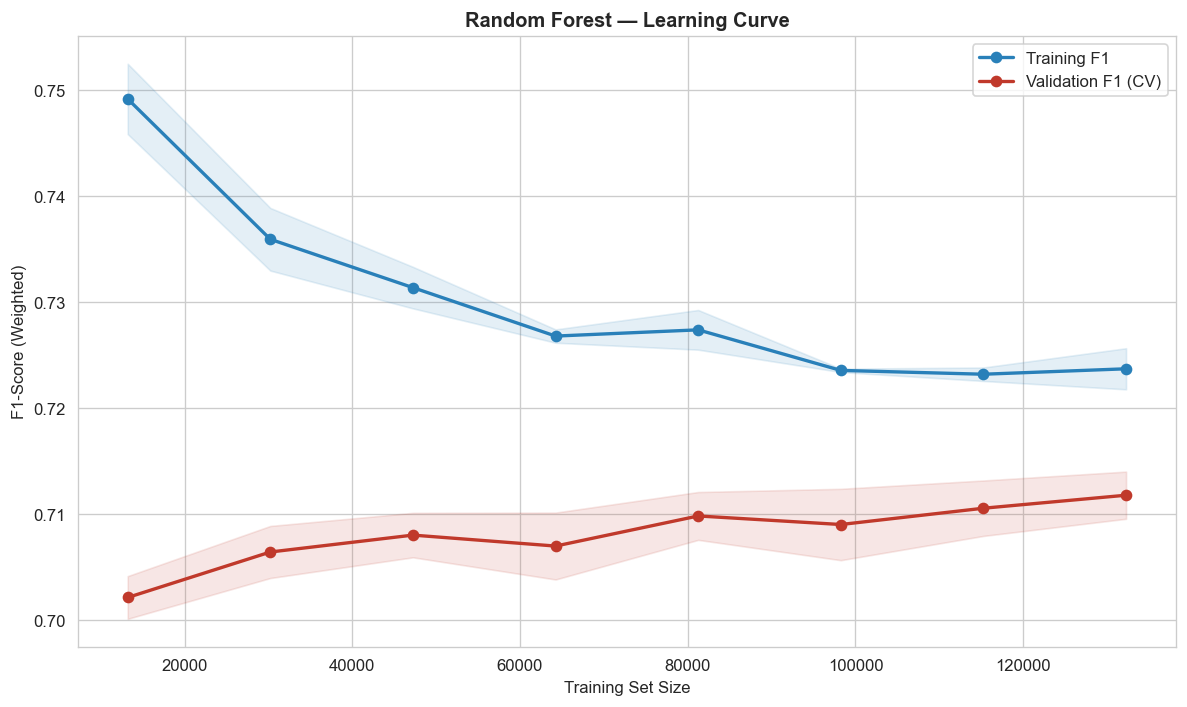

In [42]:
# 6.4 learning curve for Random Forest
# this shows how performance changes as we add more training data
# if the validation curve is still going up, we could benefit from more data

rf_for_lc = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=10, class_weight='balanced_subsample', n_jobs=-1, 
                                   random_state=RANDOM_STATE)

# 8 different training set sizes from 10% to 100%
train_sizes, train_scores, val_scores = learning_curve(rf_for_lc, X_train_prep, y_train, train_sizes=np.linspace(0.10, 1.0, 8), 
                                                       cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE), scoring='f1_weighted',
                                                       n_jobs=-1)

# average across the 3 folds
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-', color='#2980b9', lw=2, label='Training F1')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.12, color='#2980b9')

ax.plot(train_sizes, val_mean, 'o-', color='#c0392b', lw=2, label='Validation F1 (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.12, color='#c0392b')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_title('Random Forest — Learning Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_12_rf_learning_curve.png', bbox_inches='tight')
plt.show()


Random Forest — Classification Report
                   precision    recall  f1-score   support

 Low Severity (0)       0.78      0.60      0.68     24800
High Severity (1)       0.68      0.83      0.75     24800

         accuracy                           0.72     49600
        macro avg       0.73      0.72      0.71     49600
     weighted avg       0.73      0.72      0.71     49600



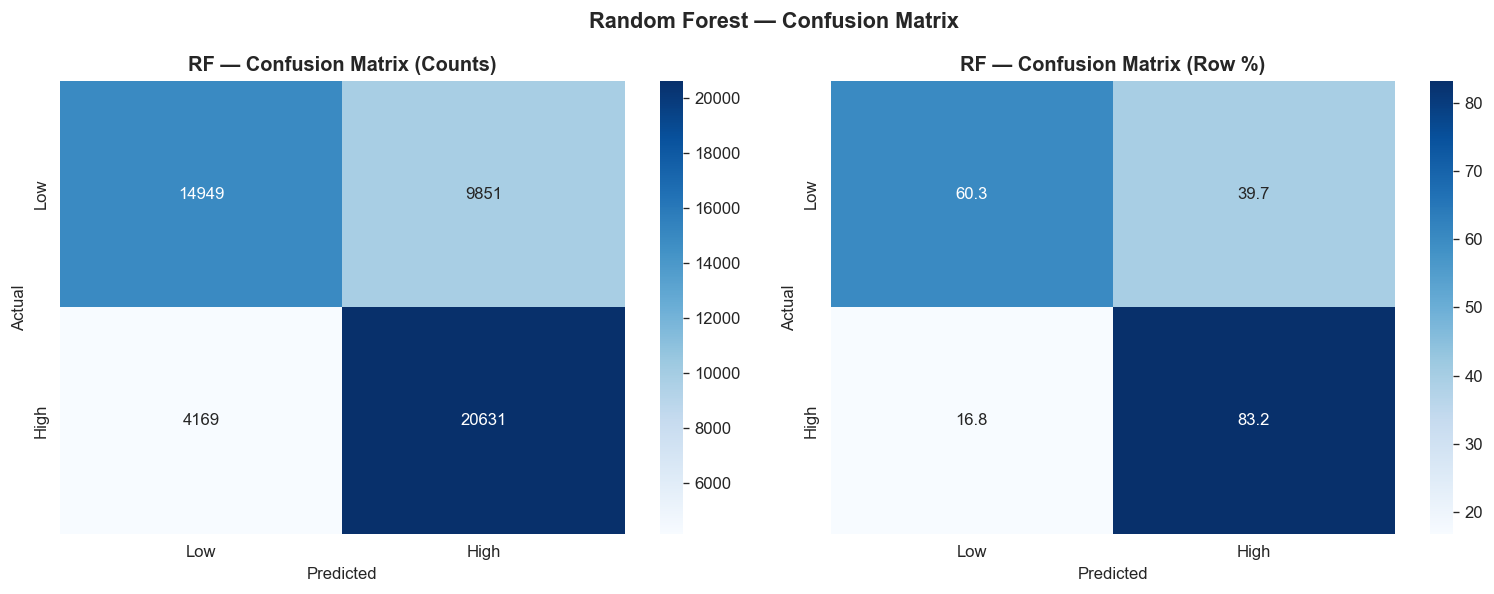

In [43]:
# 6.5 confusion matrix for Random Forest
# this shows us how many predictions were correct/wrong for each class

print('Random Forest — Classification Report')
print('=' * 55)
print(classification_report(
    y_test,
    rf_res['y_pred'],
    target_names=['Low Severity (0)', 'High Severity (1)']
))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: raw counts
cm_raw = rf_res['CM']
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[0].set_title('RF — Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# right: row percentages (easier to see recall per class)
cm_pct = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1], xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[1].set_title('RF — Confusion Matrix (Row %)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_13_rf_cm.png', bbox_inches='tight')
plt.show()


---
## 7. Gradient Boosting (Histogram-Based)

Gradient Boosting is different from Random Forest.  
Instead of building trees in parallel, it builds them one at a time.  
Each new tree tries to fix the mistakes of the previous ones.  

We use HistGradientBoostingClassifier which uses histogram binning (similar to LightGBM).  
It's much faster than the classic version and handles large datasets well.


In [44]:
# 7.1 train the main Gradient Boosting model

gb_model = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=6, min_samples_leaf=20, l2_regularization=0.1,  )

t0 = time.time()
gb_model.fit(X_train_prep, y_train)
gb_time = time.time() - t0

gb_res = evaluate_model('Gradient Boosting', gb_model, X_test_prep, y_test, gb_time)


Gradient Boosting
  Accuracy : 0.7515
  F1 Score : 0.751
  ROC-AUC  : 0.8341
  Time     : 3.5 s



Testing different learning rates...
  lr = 0.005  Acc = 0.698  AUC = 0.786
  lr = 0.01  Acc = 0.7127  AUC = 0.7982
  lr = 0.03  Acc = 0.7424  AUC = 0.825
  lr = 0.05  Acc = 0.7519  AUC = 0.834
  lr = 0.08  Acc = 0.7574  AUC = 0.8402
  lr = 0.1  Acc = 0.7591  AUC = 0.8424
  lr = 0.15  Acc = 0.7631  AUC = 0.8471
  lr = 0.2  Acc = 0.7677  AUC = 0.8501


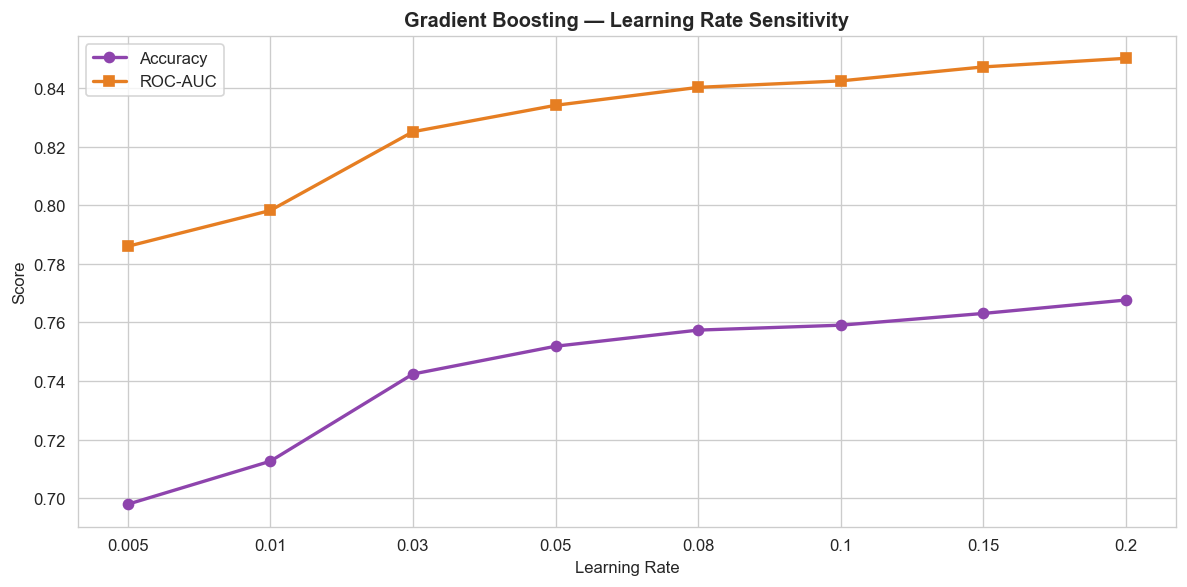

In [45]:
# 7.2 sensitivity analysis: how does learning rate affect performance?
# a low learning rate means each tree makes small steps — more careful but needs more trees
# a high learning rate means big steps — can overshoot

print('Testing different learning rates...')

learning_rates = [0.005, 0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2]
lr_acc = []
lr_auc = []

for lr in learning_rates:
    model = HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=lr,
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_prep, y_train)

    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]

    lr_acc.append(accuracy_score(y_test, y_pred))
    lr_auc.append(roc_auc_score(y_test, y_proba))

    print('  lr =', lr, ' Acc =', round(lr_acc[-1], 4), ' AUC =', round(lr_auc[-1], 4))

fig, ax = plt.subplots(figsize=(10, 5))
lr_labels = [str(lr) for lr in learning_rates]
ax.plot(lr_labels, lr_acc, 'o-', color='#8e44ad', lw=2, label='Accuracy')
ax.plot(lr_labels, lr_auc, 's-', color='#e67e22', lw=2, label='ROC-AUC')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Score')
ax.set_title('Gradient Boosting — Learning Rate Sensitivity', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_14_gb_lr.png', bbox_inches='tight')
plt.show()


In [46]:
# 7.3 sensitivity analysis: how many boosting rounds do we need?

print('Testing different numbers of boosting rounds...')

iterations = [20, 40, 60, 80, 100, 150, 200, 250]
iter_acc = []
iter_auc = []

for n_iter in iterations:
    model = HistGradientBoostingClassifier(
        max_iter=n_iter,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_prep, y_train)

    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]

    iter_acc.append(accuracy_score(y_test, y_pred))
    iter_auc.append(roc_auc_score(y_test, y_proba))

    print('  iter =', n_iter, ' Acc =', round(iter_acc[-1], 4), ' AUC =', round(iter_auc[-1], 4))


Testing different numbers of boosting rounds...
  iter = 20  Acc = 0.697  AUC = 0.785
  iter = 40  Acc = 0.7122  AUC = 0.7984
  iter = 60  Acc = 0.7257  AUC = 0.8074
  iter = 80  Acc = 0.7326  AUC = 0.8142
  iter = 100  Acc = 0.7385  AUC = 0.8207
  iter = 150  Acc = 0.747  AUC = 0.8295
  iter = 200  Acc = 0.7519  AUC = 0.834
  iter = 250  Acc = 0.7547  AUC = 0.8368


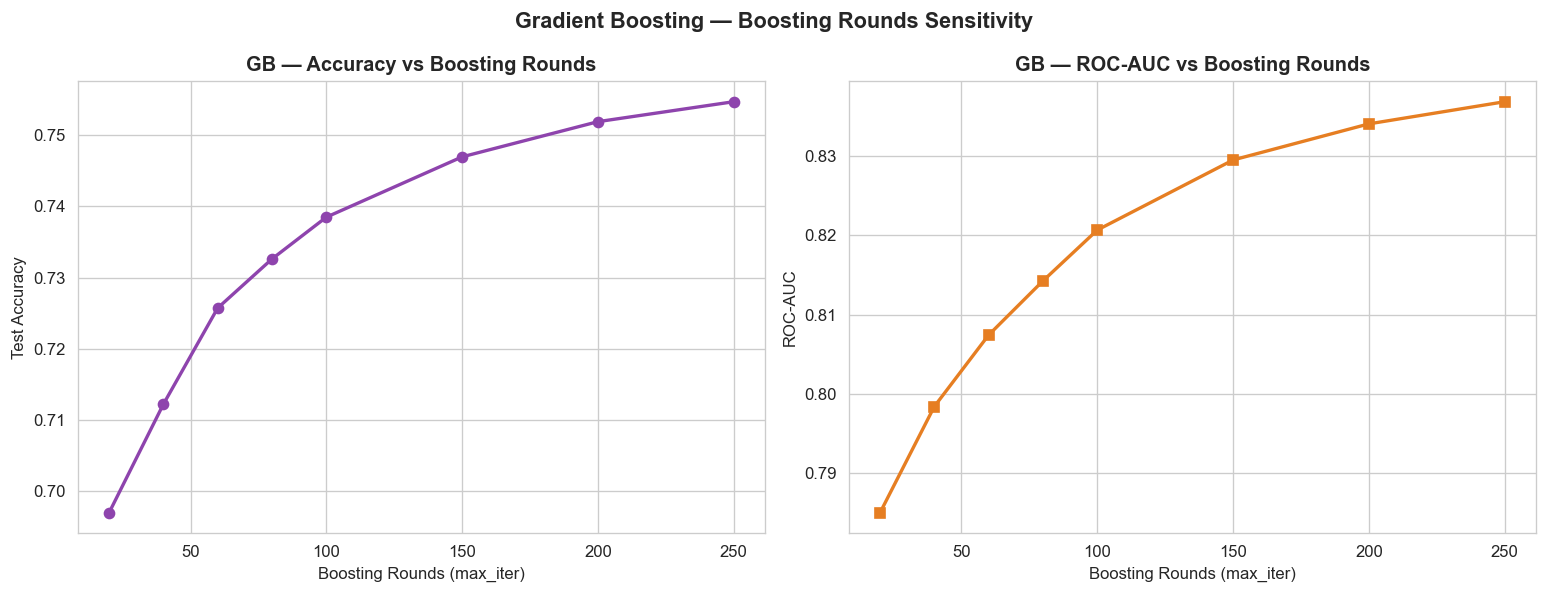

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(iterations, iter_acc, 'o-', color='#8e44ad', lw=2)
axes[0].set_xlabel('Boosting Rounds (max_iter)')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('GB — Accuracy vs Boosting Rounds', fontweight='bold')

axes[1].plot(iterations, iter_auc, 's-', color='#e67e22', lw=2)
axes[1].set_xlabel('Boosting Rounds (max_iter)')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('GB — ROC-AUC vs Boosting Rounds', fontweight='bold')

plt.suptitle('Gradient Boosting — Boosting Rounds Sensitivity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_15_gb_iters.png', bbox_inches='tight')
plt.show()

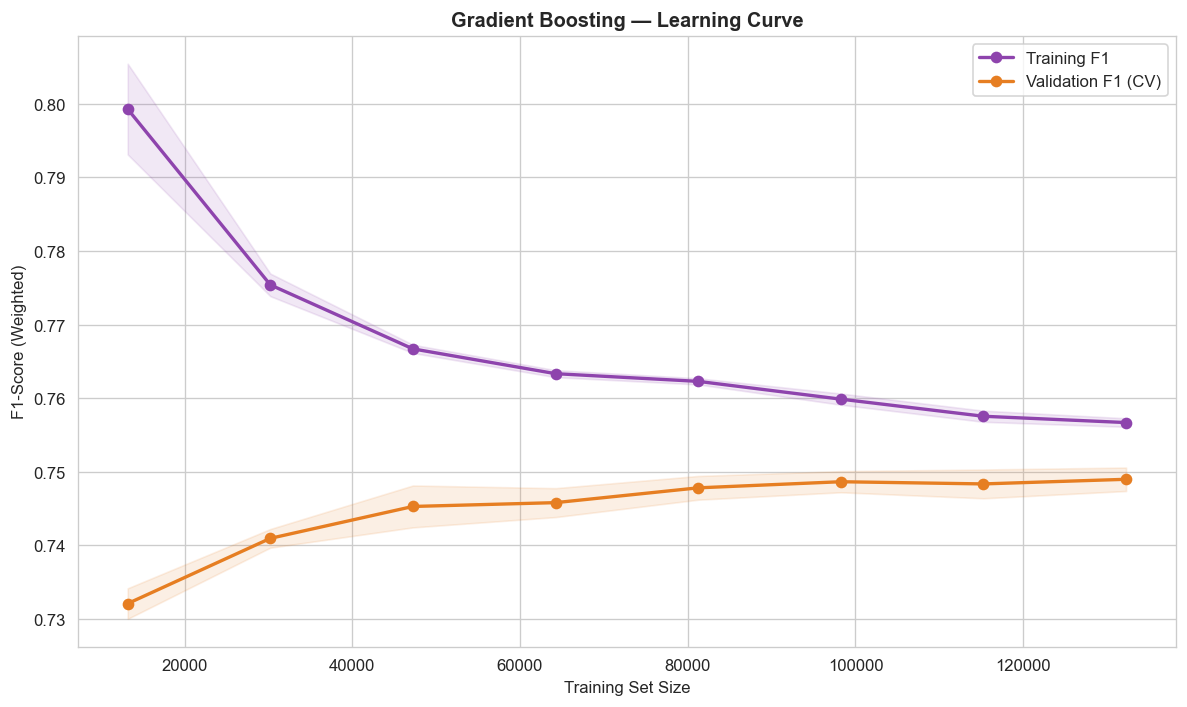

In [48]:
# 7.4 learning curve for Gradient Boosting

gb_for_lc = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

train_sizes_gb, train_scores_gb, val_scores_gb = learning_curve(
    gb_for_lc,
    X_train_prep,
    y_train,
    train_sizes=np.linspace(0.10, 1.0, 8),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_weighted',
    n_jobs=-1
)

tr_mean_gb = train_scores_gb.mean(axis=1)
tr_std_gb = train_scores_gb.std(axis=1)
val_mean_gb = val_scores_gb.mean(axis=1)
val_std_gb = val_scores_gb.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes_gb, tr_mean_gb, 'o-', color='#8e44ad', lw=2, label='Training F1')
ax.fill_between(train_sizes_gb, tr_mean_gb - tr_std_gb, tr_mean_gb + tr_std_gb,
                alpha=0.12, color='#8e44ad')
ax.plot(train_sizes_gb, val_mean_gb, 'o-', color='#e67e22', lw=2, label='Validation F1 (CV)')
ax.fill_between(train_sizes_gb, val_mean_gb - val_std_gb, val_mean_gb + val_std_gb,
                alpha=0.12, color='#e67e22')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_title('Gradient Boosting — Learning Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_16_gb_learning_curve.png', bbox_inches='tight')
plt.show()


Gradient Boosting — Classification Report
                   precision    recall  f1-score   support

 Low Severity (0)       0.78      0.71      0.74     24800
High Severity (1)       0.73      0.80      0.76     24800

         accuracy                           0.75     49600
        macro avg       0.75      0.75      0.75     49600
     weighted avg       0.75      0.75      0.75     49600



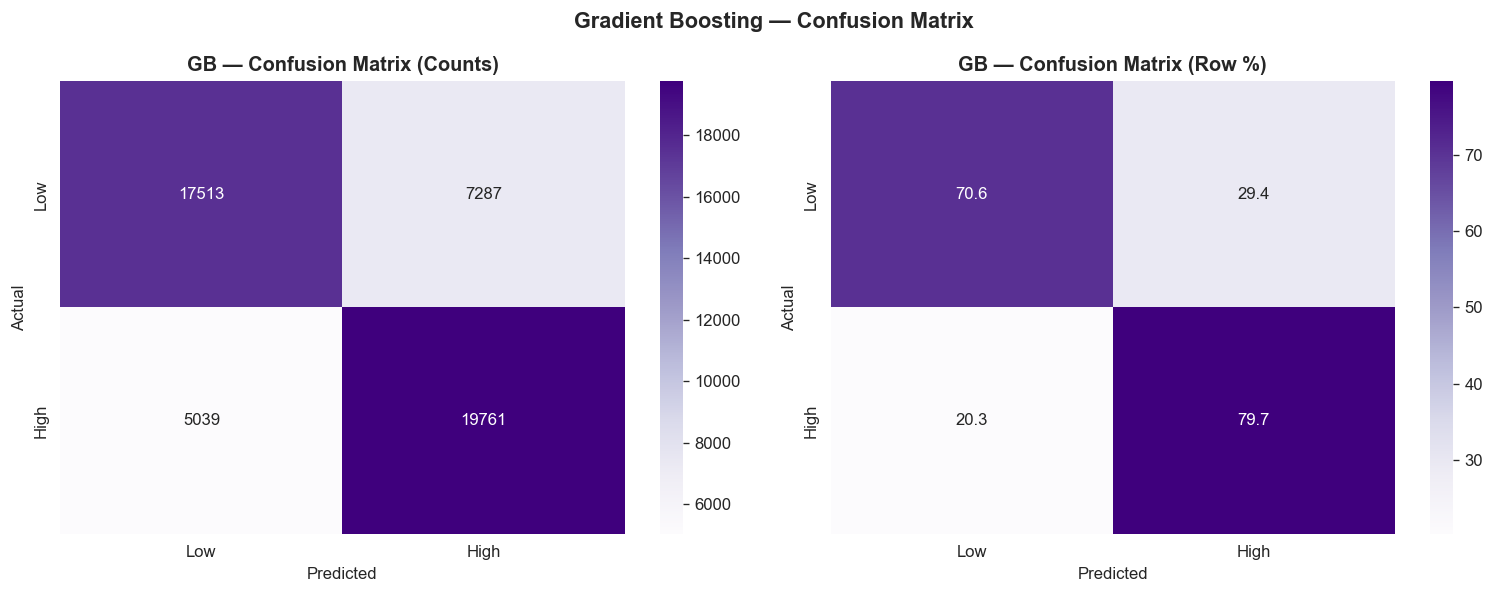

In [49]:
# 7.5 confusion matrix for Gradient Boosting

print('Gradient Boosting — Classification Report')
print('=' * 55)
print(classification_report(
    y_test,
    gb_res['y_pred'],
    target_names=['Low Severity (0)', 'High Severity (1)']
))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_gb = gb_res['CM']
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[0].set_title('GB — Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_gb_pct = cm_gb.astype(float) / cm_gb.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_gb_pct, annot=True, fmt='.1f', cmap='Purples', ax=axes[1],
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[1].set_title('GB — Confusion Matrix (Row %)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Gradient Boosting — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_17_gb_cm.png', bbox_inches='tight')
plt.show()


---
## 8. RF vs GB — Head-to-Head Comparison

In [50]:
# compare the two main models side by side

metrics_to_compare = ['Accuracy', 'F1_Weighted', 'Precision', 'Recall', 'ROC_AUC']

print('Metric          RF          GB')
print('-' * 50)

for metric in metrics_to_compare:
    rf_val = rf_res[metric]
    gb_val = gb_res[metric]
    print(metric.ljust(16), str(round(rf_val, 4)).ljust(12), str(round(gb_val, 4)).ljust(12))

print()
print('Note: RF also provides OOB score =', round(rf_model.oob_score_, 4),
      '(GB does not have this feature)')


Metric          RF          GB
--------------------------------------------------
Accuracy         0.7173       0.7515      
F1_Weighted      0.7136       0.751       
Precision        0.7294       0.7536      
Recall           0.7173       0.7515      
ROC_AUC          0.7949       0.8341      

Note: RF also provides OOB score = 0.7133 (GB does not have this feature)


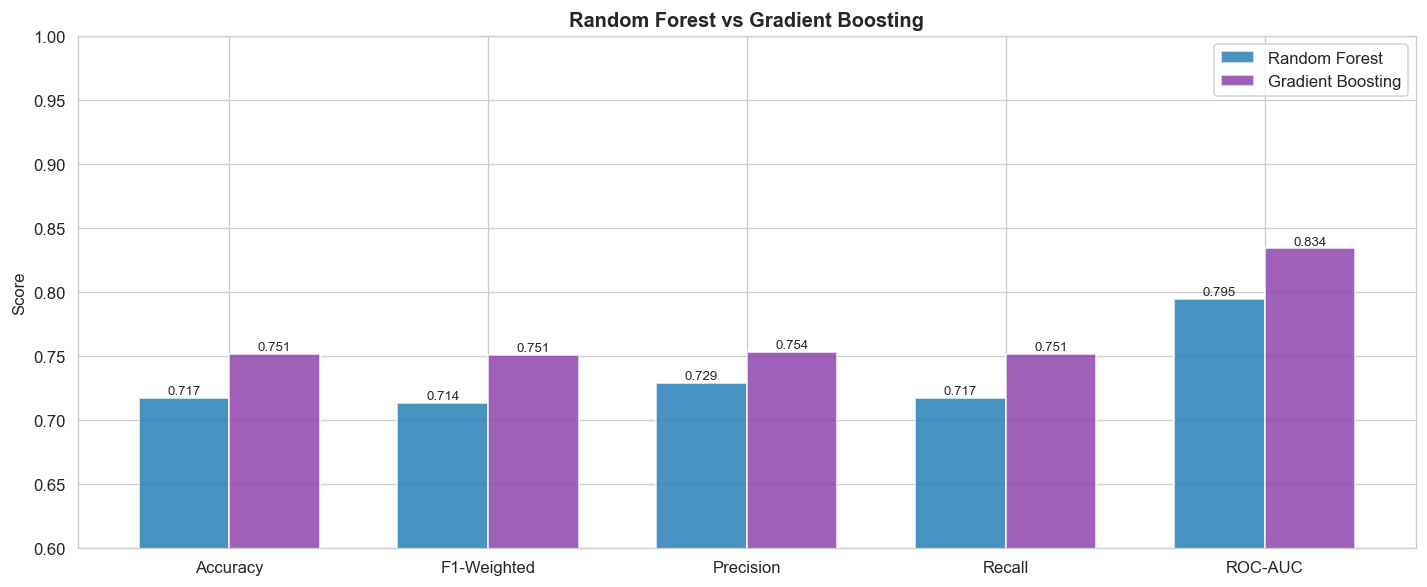

In [51]:
# bar chart comparison of RF vs GB

compare_metrics = ['Accuracy', 'F1_Weighted', 'Precision', 'Recall', 'ROC_AUC']
rf_scores = [rf_res[m] for m in compare_metrics]
gb_scores = [gb_res[m] for m in compare_metrics]

x = np.arange(len(compare_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_rf = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='#2980b9', alpha=0.85)
bars_gb = ax.bar(x + width/2, gb_scores, width, label='Gradient Boosting', color='#8e44ad', alpha=0.85)

# add value labels on top of bars
for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            str(round(bar.get_height(), 3)), ha='center', fontsize=8)
for bar in bars_gb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            str(round(bar.get_height(), 3)), ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1-Weighted', 'Precision', 'Recall', 'ROC-AUC'])
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Score')
ax.set_title('Random Forest vs Gradient Boosting', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_18_rf_vs_gb.png', bbox_inches='tight')
plt.show()


---
## 9. Ensemble Methods

Can we do even better by combining multiple models?  

- **Hard Voting**: each model votes for a class, majority wins
- **Soft Voting**: average the predicted probabilities, pick the highest
- **Stacking**: train a meta-model (Logistic Regression) on the outputs of RF and GB


In [52]:
# define the base models for the ensemble
# we use fresh copies so they are not already fitted

rf_base = RandomForestClassifier(
    n_estimators=100, max_depth=12, min_samples_leaf=10,
    class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE
)
gb_base = HistGradientBoostingClassifier(
    max_iter=200, learning_rate=0.05, max_depth=6,
    min_samples_leaf=20, random_state=RANDOM_STATE
)
dt_base = DecisionTreeClassifier(
    max_depth=8, class_weight='balanced', random_state=RANDOM_STATE
)

# Hard Voting: majority vote on class labels
hard_voter = VotingClassifier(
    estimators=[('rf', rf_base), ('gb', gb_base), ('dt', dt_base)],
    voting='hard',
    n_jobs=-1
)

# Soft Voting: average the probabilities (usually better than hard voting)
soft_voter = VotingClassifier(
    estimators=[('rf', rf_base), ('gb', gb_base), ('dt', dt_base)],
    voting='soft',
    n_jobs=-1
)

# Stacking: Logistic Regression learns how to best combine RF and GB
stacking = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(
            n_estimators=100, max_depth=12, min_samples_leaf=10,
            class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE
        )),
        ('gb', HistGradientBoostingClassifier(
            max_iter=200, learning_rate=0.05, max_depth=6,
            min_samples_leaf=20, random_state=RANDOM_STATE
        )),
    ],
    final_estimator=LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

In [53]:
# train and evaluate all ensemble methods
ensemble_results = {}

for ensemble_name, ensemble_model in [('Hard Voting', hard_voter),
                                        ('Soft Voting', soft_voter),
                                        ('Stacking (RF+GB->LR)', stacking)]:
    print('Training:', ensemble_name, '...')
    t0 = time.time()
    ensemble_model.fit(X_train_prep, y_train)
    t1 = time.time() - t0

    result = evaluate_model(ensemble_name, ensemble_model, X_test_prep, y_test, t1)
    ensemble_results[ensemble_name] = result


Training: Hard Voting ...
Hard Voting
  Accuracy : 0.734
  F1 Score : 0.7315
  ROC-AUC  : 0.734
  Time     : 15.8 s

Training: Soft Voting ...
Soft Voting
  Accuracy : 0.7337
  F1 Score : 0.7317
  ROC-AUC  : 0.8191
  Time     : 15.6 s

Training: Stacking (RF+GB->LR) ...
Stacking (RF+GB->LR)
  Accuracy : 0.7518
  F1 Score : 0.7515
  ROC-AUC  : 0.8342
  Time     : 43.0 s



---
## 10. Cross-Validation

In [54]:
# 5-fold cross-validation for all models
# we use a subset of the training data to keep it reasonably fast

# sample 30,000 rows from training data
cv_size = min(30000, len(X_train_prep))
rng = np.random.RandomState(RANDOM_STATE)
cv_idx = rng.choice(len(X_train_prep), cv_size, replace=False)
X_cv = X_train_prep[cv_idx]
y_cv = y_train.values[cv_idx]

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# models to cross-validate
cv_models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Reg': LogisticRegression(C=1.0, max_iter=500, class_weight='balanced',
                                        random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced',
                                              random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12,
                                              min_samples_leaf=10,
                                              class_weight='balanced_subsample',
                                              n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                                          max_depth=6, min_samples_leaf=20,
                                                          random_state=RANDOM_STATE),
}

cv_results = {}


for name, model in cv_models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=kfold, scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(name + ':')
    print('  Mean F1:', round(scores.mean(), 4), '  Std:', round(scores.std(), 4))


Naive Bayes:
  Mean F1: 0.596   Std: 0.0515
Logistic Reg:
  Mean F1: 0.6555   Std: 0.0056
Decision Tree:
  Mean F1: 0.6878   Std: 0.0123
Random Forest:
  Mean F1: 0.7077   Std: 0.0033
Gradient Boosting:
  Mean F1: 0.7419   Std: 0.0024


In [55]:
# 5-fold cross-validation for all models
# we use a subset of the training data to keep it reasonably fast

cv_size = min(30000, len(X_train_prep))

rng = np.random.RandomState(RANDOM_STATE)
cv_idx = rng.choice(len(X_train_prep), cv_size, replace=False)

X_cv = X_train_prep[cv_idx]
y_cv = y_train.values[cv_idx]

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# models
cv_models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Reg': LogisticRegression(C=1.0, max_iter=500,
                                       class_weight='balanced',
                                       random_state=RANDOM_STATE),

    'Decision Tree': DecisionTreeClassifier(max_depth=8,
                                            class_weight='balanced',
                                            random_state=RANDOM_STATE),

    'Random Forest': RandomForestClassifier(n_estimators=100,
                                            max_depth=12,
                                            min_samples_leaf=10,
                                            class_weight='balanced_subsample',
                                            n_jobs=-1,
                                            random_state=RANDOM_STATE),

    'Gradient Boosting': HistGradientBoostingClassifier(max_iter=200,
                                                        learning_rate=0.05,
                                                        max_depth=6,
                                                        min_samples_leaf=20,
                                                        random_state=RANDOM_STATE)
}

cv_results = {}


for name, model in cv_models.items():

    scores = cross_val_score(model, X_cv, y_cv,
                             cv=kfold,
                             scoring='f1_weighted',
                             n_jobs=-1)

    cv_results[name] = scores

    mean_score = scores.mean()
    std_score = scores.std()

    print(name)
    print('Mean F1 =', round(mean_score,4),
          'Std =', round(std_score,4))

Naive Bayes
Mean F1 = 0.596 Std = 0.0515
Logistic Reg
Mean F1 = 0.6555 Std = 0.0056
Decision Tree
Mean F1 = 0.6878 Std = 0.0123
Random Forest
Mean F1 = 0.7077 Std = 0.0033
Gradient Boosting
Mean F1 = 0.7419 Std = 0.0024


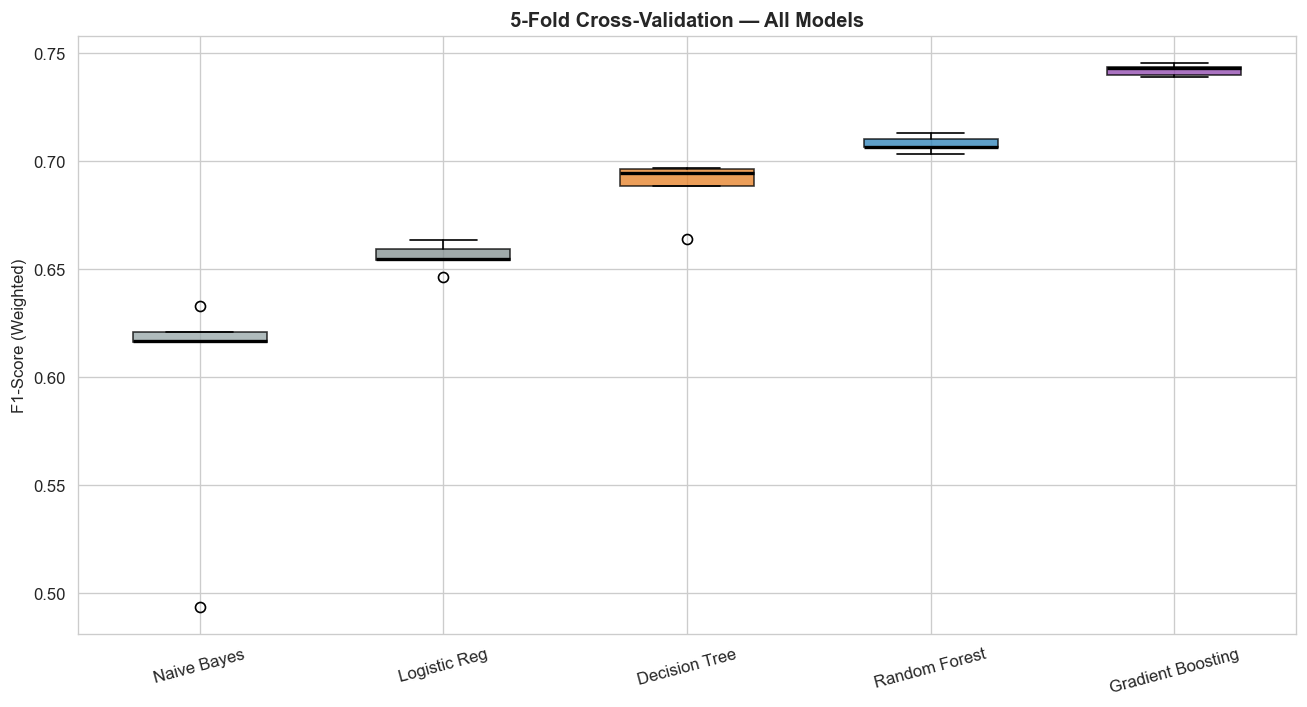

In [56]:
# boxplot of cross-validation scores
fig, ax = plt.subplots(figsize=(11, 6))

cv_names = list(cv_results.keys())
cv_data = [cv_results[name] for name in cv_names]
palette = ['#95a5a6', '#7f8c8d', '#e67e22', '#2980b9', '#8e44ad']

bp = ax.boxplot(cv_data, labels=cv_names, patch_artist=True, widths=0.55)

for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_ylabel('F1-Score (Weighted)')
ax.set_title('5-Fold Cross-Validation — All Models', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('fig_20_cross_validation.png', bbox_inches='tight')
plt.show()


---
## 11. Feature Importance

In [57]:
# get the feature names after preprocessing
# the categorical features got split into many columns by one-hot encoding

# get the names from the OneHotEncoder
ohe_feature_names = (
    preprocessor
    .named_transformers_['categorical']['encode']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)

# combine all feature names in the right order
all_feature_names = NUMERIC_FEATURES + ohe_feature_names + BINARY_FEATURES

print('Total number of features after encoding:', len(all_feature_names))
print('First 10 feature names:', all_feature_names[:10])


Total number of features after encoding: 74
First 10 feature names: ['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)', 'Hour', 'DayOfWeek']


In [58]:
# helper function to get feature importance
# Random Forest has a built-in importance score (Gini importance)
# Gradient Boosting (HistGB) doesn't, so we use permutation importance

def get_feature_importance(model, X, y, feature_names):
    if hasattr(model, 'feature_importances_'):
        # Random Forest: use native Gini importance
        importance = model.feature_importances_
        return pd.Series(importance, index=feature_names)
    else:
        # Gradient Boosting: use permutation importance on a small sample
        # (permutation importance shuffles each feature and sees how much performance drops)
        np.random.seed(RANDOM_STATE)
        sample_size = min(5000, len(X))
        idx = np.random.choice(len(X), sample_size, replace=False)

        if hasattr(y, 'values'):
            y_sample = y.values[idx]
        else:
            y_sample = y[idx]

        perm = permutation_importance(
            model, X[idx], y_sample,
            n_repeats=5,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        return pd.Series(perm.importances_mean, index=feature_names)


rf_importance = get_feature_importance(rf_model, X_test_prep, y_test, all_feature_names)
gb_importance = get_feature_importance(gb_model, X_test_prep, y_test, all_feature_names)


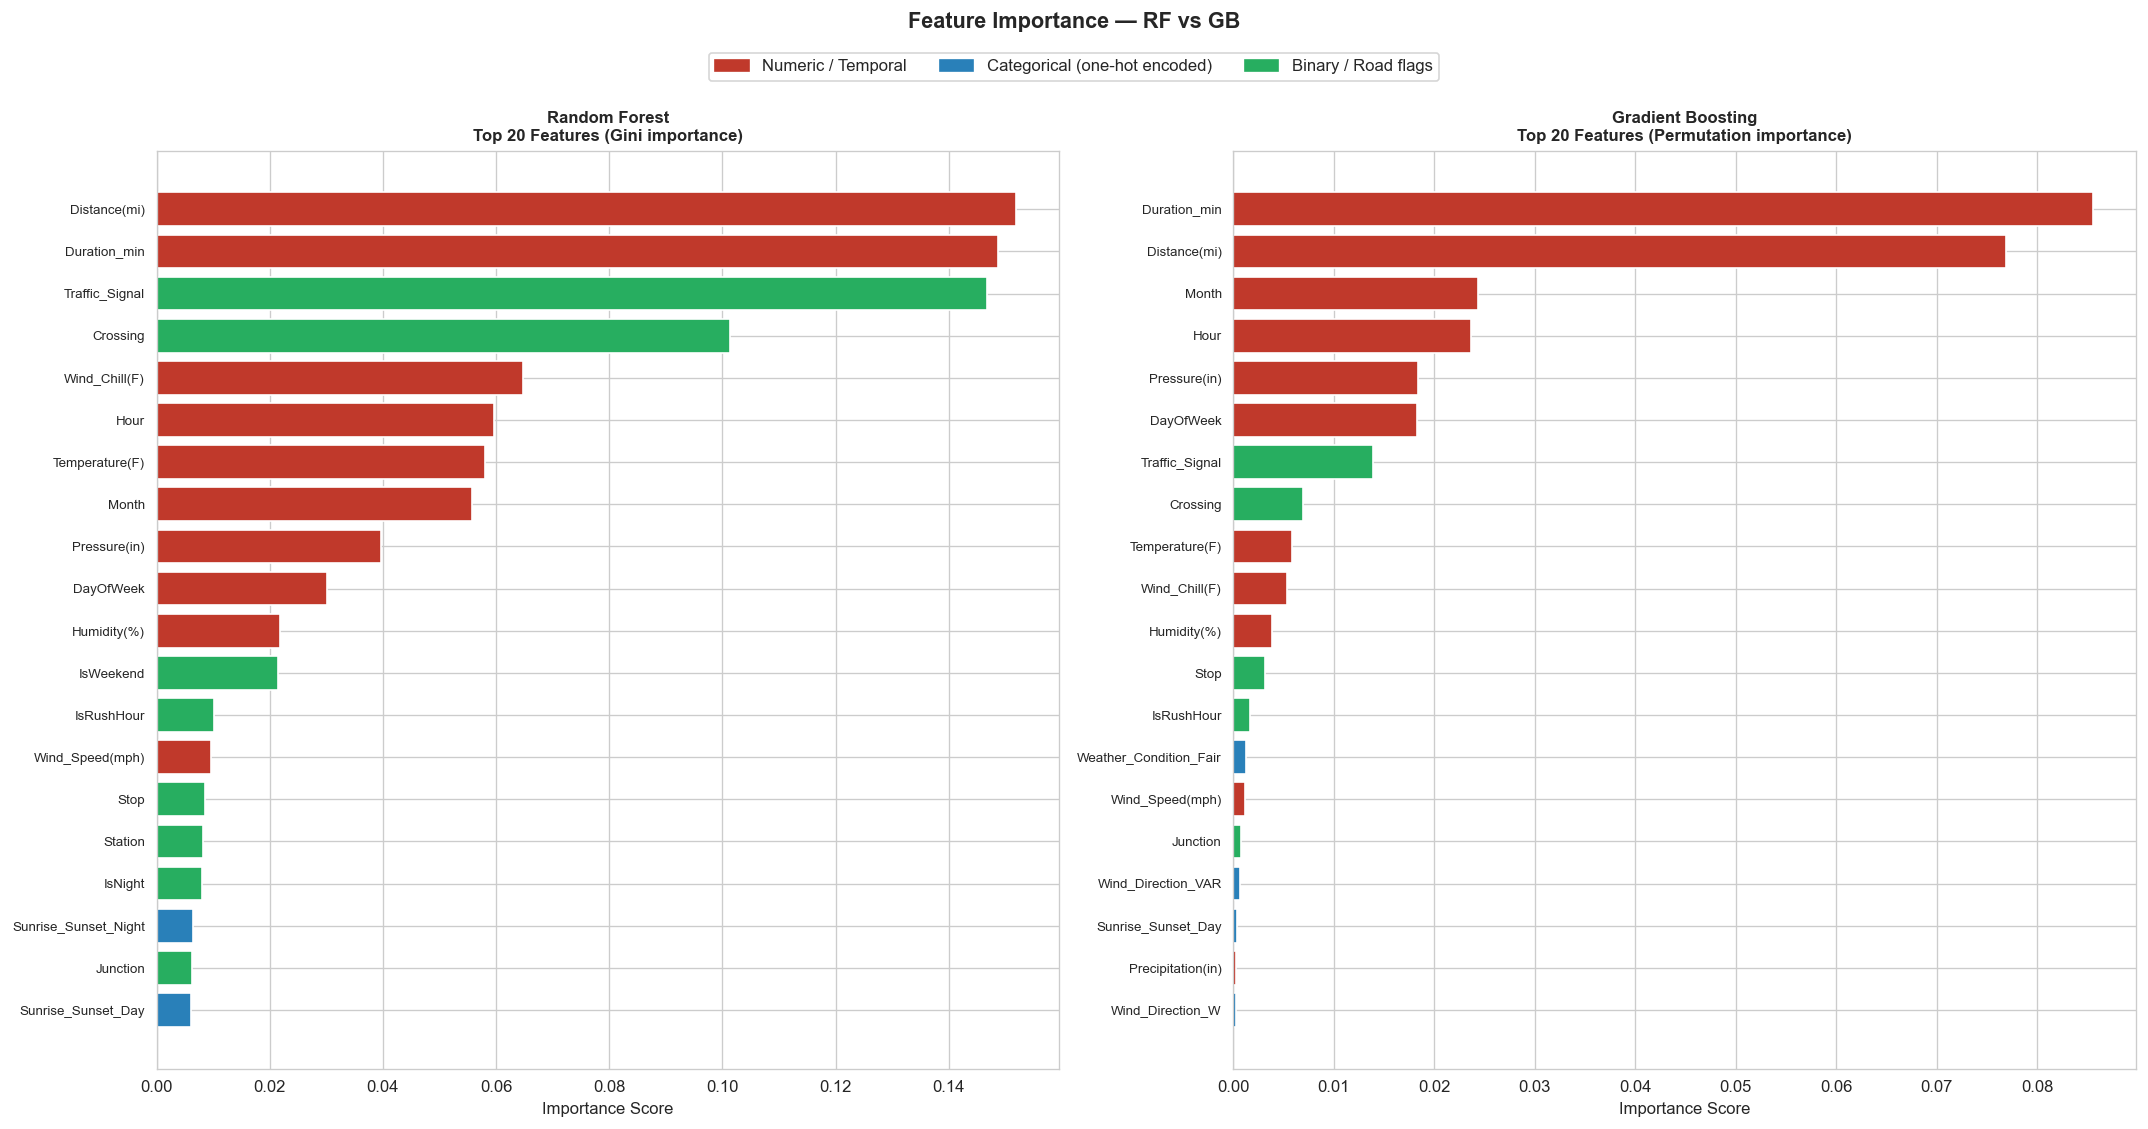

In [59]:
# a simple helper function to color features by type
# red = numeric, blue = categorical, green = binary/road flags

def get_bar_color(feature_name):
    if feature_name in NUMERIC_FEATURES:
        return '#c0392b'  
    for cat in CATEGORICAL_FEATURES:
        if feature_name.startswith(cat):
            return '#2980b9'  
    return '#27ae60'  


# side-by-side: top 20 features for RF and GB
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, importance, title, method in [
    (axes[0], rf_importance, 'Random Forest', '(Gini importance)'),
    (axes[1], gb_importance, 'Gradient Boosting', '(Permutation importance)')
]:
    top20 = importance.sort_values(ascending=False).head(20)
    bar_colors = [get_bar_color(name) for name in top20.index]

    ax.barh(range(len(top20)), top20.values[::-1], color=bar_colors[::-1])
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels([name[:35] for name in top20.index[::-1]], fontsize=8)
    ax.set_title(title + '\nTop 20 Features ' + method, fontweight='bold', fontsize=10)
    ax.set_xlabel('Importance Score')

# add a legend
legend_items = [
    mpatches.Patch(color='#c0392b', label='Numeric / Temporal'),
    mpatches.Patch(color='#2980b9', label='Categorical (one-hot encoded)'),
    mpatches.Patch(color='#27ae60', label='Binary / Road flags')
]
fig.legend(handles=legend_items, loc='upper center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 1.01))

plt.suptitle('Feature Importance — RF vs GB', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('fig_21_feature_importance.png', bbox_inches='tight')
plt.show()


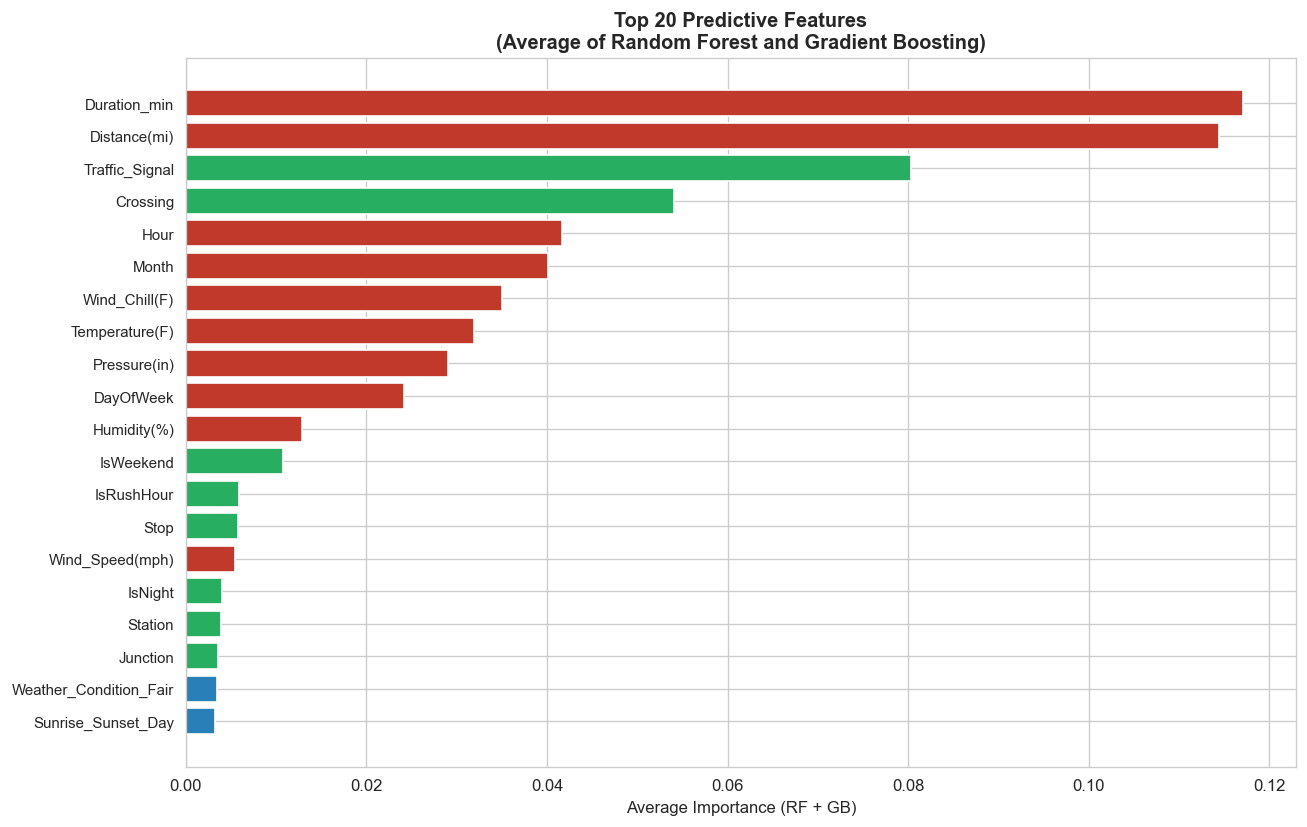

In [60]:
# average the two importance scores to get a consensus ranking

avg_importance = ((rf_importance + gb_importance) / 2).sort_values(ascending=False).head(20)
avg_colors = [get_bar_color(name) for name in avg_importance.index]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(avg_importance)), avg_importance.values[::-1], color=avg_colors[::-1])
ax.set_yticks(range(len(avg_importance)))
ax.set_yticklabels([name[:40] for name in avg_importance.index[::-1]], fontsize=9)
ax.set_xlabel('Average Importance (RF + GB)')
ax.set_title('Top 20 Predictive Features\n(Average of Random Forest and Gradient Boosting)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_22_consensus_importance.png', bbox_inches='tight')
plt.show()



---
## 12. Error Analysis

In [61]:
# collect all results into one dictionary so we can compare everything

all_results = {}
all_results.update(baseline_results)
all_results['Random Forest'] = rf_res
all_results['Gradient Boosting'] = gb_res
all_results.update(ensemble_results)

# find the best model by ROC-AUC
best_name = max(all_results, key=lambda k: all_results[k]['ROC_AUC'])
best_res = all_results[best_name]

print('Best model by ROC-AUC:', best_name)
print('ROC-AUC:', round(best_res['ROC_AUC'], 4))


Best model by ROC-AUC: Stacking (RF+GB->LR)
ROC-AUC: 0.8342


In [62]:
# look at where the best model makes mistakes

# build a dataframe of test predictions
error_df = X_test.reset_index(drop=True).copy()
error_df['true_label'] = y_test.reset_index(drop=True).values
error_df['pred_label'] = best_res['y_pred']
error_df['pred_proba'] = best_res['y_proba']
error_df['is_correct'] = (error_df['true_label'] == error_df['pred_label'])

# separate the two main error types
# false negatives = predicted Low but actually High (the dangerous ones to miss!)
# false positives = predicted High but actually Low
false_negatives = error_df[(error_df['true_label'] == 1) & (error_df['pred_label'] == 0)]
false_positives = error_df[(error_df['true_label'] == 0) & (error_df['pred_label'] == 1)]

n_total = len(y_test)
n_correct = error_df['is_correct'].sum()

print('Model:', best_name)
print('Test set size:', n_total)
print('Correct predictions:', n_correct, '(' + str(round(n_correct/n_total*100, 2)) + '%)')
print('False Negatives (missed high severity):', len(false_negatives),
      '(' + str(round(len(false_negatives)/n_total*100, 2)) + '%)')
print('False Positives (wrong high severity alarm):', len(false_positives),
      '(' + str(round(len(false_positives)/n_total*100, 2)) + '%)')
print()
print('NOTE: False Negatives are the more serious error for this application.')
print('Missing a high-severity accident could mean delayed emergency response.')


Model: Stacking (RF+GB->LR)
Test set size: 49600
Correct predictions: 37288 (75.18%)
False Negatives (missed high severity): 5399 (10.89%)
False Positives (wrong high severity alarm): 6913 (13.94%)

NOTE: False Negatives are the more serious error for this application.
Missing a high-severity accident could mean delayed emergency response.


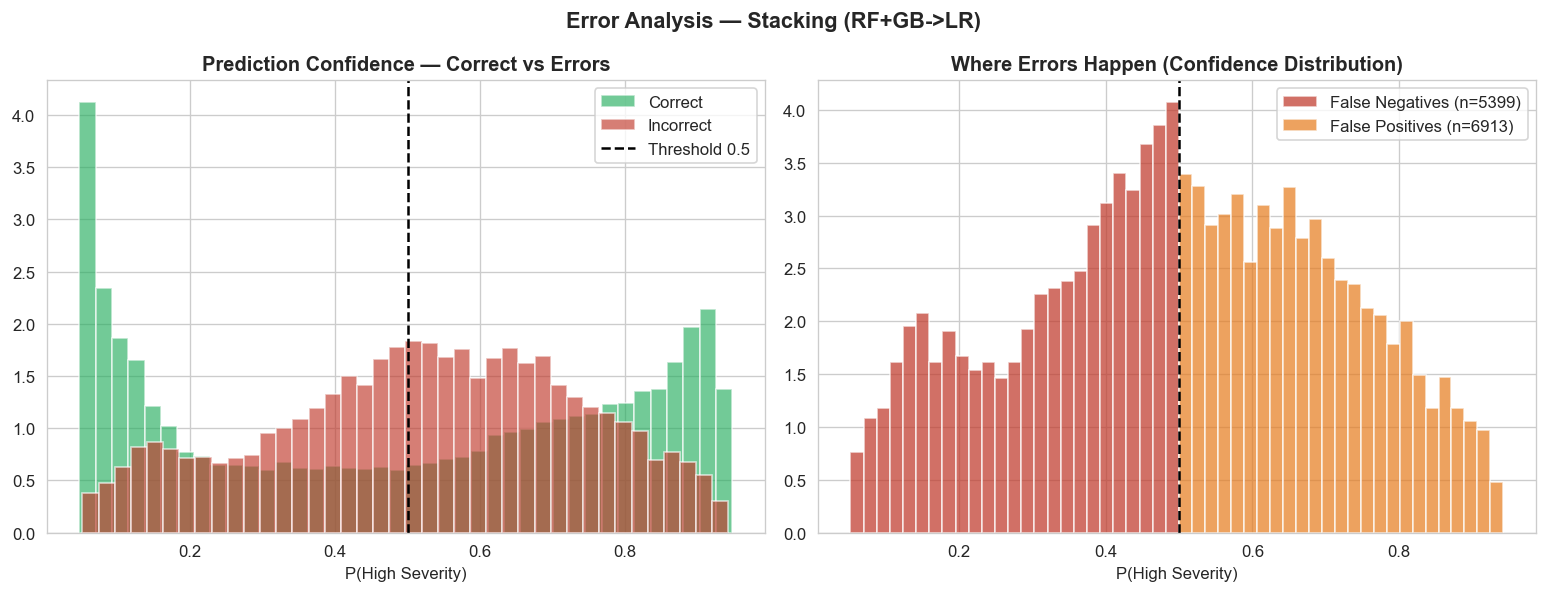

In [63]:
# plot the confidence of correct vs incorrect predictions

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: how confident is the model for correct vs wrong predictions?
correct_mask = error_df['is_correct']
axes[0].hist(error_df[correct_mask]['pred_proba'], bins=40,
             alpha=0.65, label='Correct', color='#27ae60', density=True)
axes[0].hist(error_df[~correct_mask]['pred_proba'], bins=40,
             alpha=0.65, label='Incorrect', color='#c0392b', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.5')
axes[0].set_title('Prediction Confidence — Correct vs Errors', fontweight='bold')
axes[0].set_xlabel('P(High Severity)')
axes[0].legend()

# right: where do FN and FP cluster?
axes[1].hist(false_negatives['pred_proba'], bins=25, alpha=0.72,
             label='False Negatives (n=' + str(len(false_negatives)) + ')',
             color='#c0392b', density=True)
axes[1].hist(false_positives['pred_proba'], bins=25, alpha=0.72,
             label='False Positives (n=' + str(len(false_positives)) + ')',
             color='#e67e22', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Where Errors Happen (Confidence Distribution)', fontweight='bold')
axes[1].set_xlabel('P(High Severity)')
axes[1].legend()

plt.suptitle('Error Analysis — ' + best_name, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_24_error_analysis.png', bbox_inches='tight')
plt.show()


In [64]:
# final results table — all models sorted by ROC-AUC

rows = []
for name, res in all_results.items():
    rows.append({
        'Model': res['name'],
        'Accuracy': round(res['Accuracy'], 4),
        'F1-W': round(res['F1_Weighted'], 4),
        'Precision': round(res['Precision'], 4),
        'Recall': round(res['Recall'], 4),
        'ROC-AUC': round(res['ROC_AUC'], 4),
        'Time(s)': round(res['Train_Time'], 1)
    })

summary_df = pd.DataFrame(rows)
summary_df = summary_df.set_index('Model')
summary_df = summary_df.sort_values('ROC-AUC', ascending=False)

print('All Models — Final Results (sorted by ROC-AUC):')
print(summary_df.to_string())


All Models — Final Results (sorted by ROC-AUC):
                      Accuracy    F1-W  Precision  Recall  ROC-AUC  Time(s)
Model                                                                      
Stacking (RF+GB->LR)    0.7518  0.7515     0.7527  0.7518   0.8342     43.0
Gradient Boosting       0.7515  0.7510     0.7536  0.7515   0.8341      3.5
Soft Voting             0.7337  0.7317     0.7409  0.7337   0.8191     15.6
Random Forest           0.7173  0.7136     0.7294  0.7173   0.7949      5.0
Decision Tree           0.6921  0.6873     0.7045  0.6921   0.7635      1.4
Hard Voting             0.7340  0.7315     0.7428  0.7340   0.7340     15.8
Logistic Regression     0.6564  0.6562     0.6568  0.6564   0.7101      1.2
Naive Bayes             0.6121  0.6058     0.6198  0.6121   0.6802      0.1


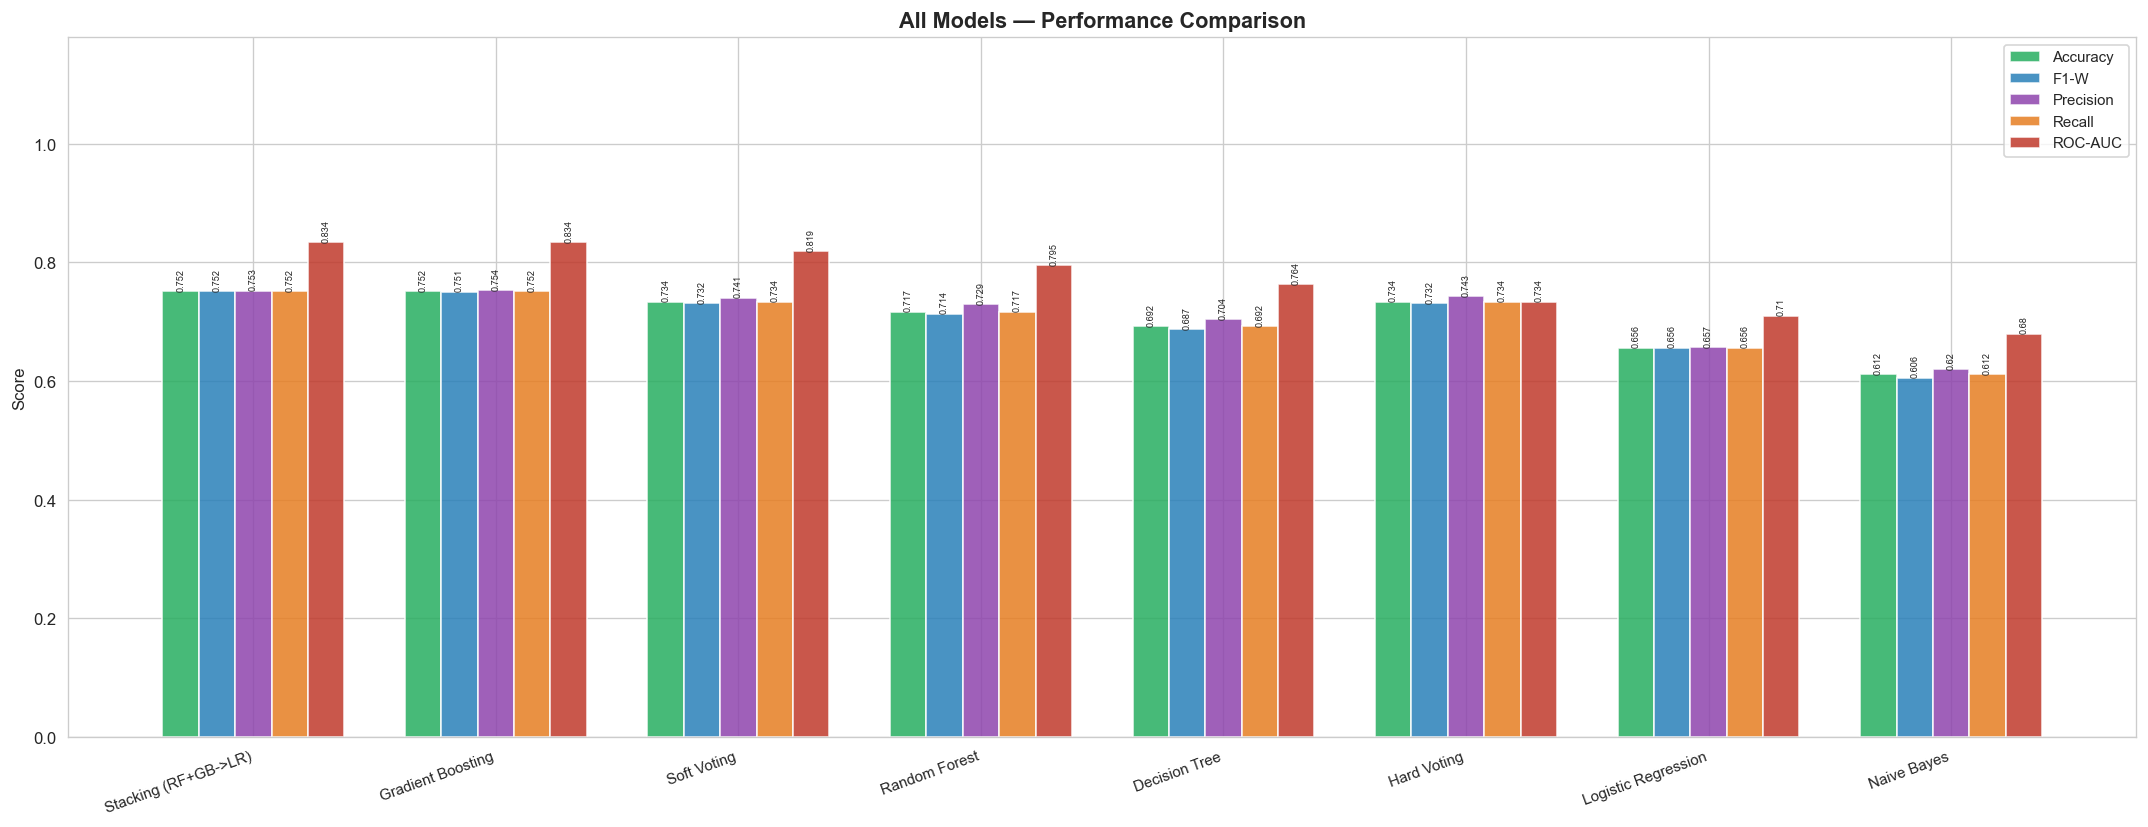

In [65]:
# grouped bar chart showing all models

all_model_names = summary_df.index.tolist()
metrics_to_plot = ['Accuracy', 'F1-W', 'Precision', 'Recall', 'ROC-AUC']
bar_colors = ['#27ae60', '#2980b9', '#8e44ad', '#e67e22', '#c0392b']

x = np.arange(len(all_model_names))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(18, 7))

for i, (metric, color) in enumerate(zip(metrics_to_plot, bar_colors)):
    values = summary_df[metric].values
    bars = ax.bar(x + i * bar_width, values, bar_width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')

    # add small value labels on top
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                str(round(bar.get_height(), 3)), ha='center', fontsize=5.5, rotation=90)

ax.set_xticks(x + bar_width * 2)
ax.set_xticklabels(all_model_names, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('All Models — Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_25_all_models.png', bbox_inches='tight')
plt.show()


##  Conclusions  
## Traffic Accident Severity Prediction

---

## Dataset and Setup

- We used **{SAMPLES_PER_CLASS * 4} balanced records**  
  ({SAMPLES_PER_CLASS} per severity class)
- Data was **split before EDA and feature engineering** to avoid data leakage.
- Binary target definition:
  - **Low Severity:** 1–2  
  - **High Severity:** 3–4

---

## Baseline Models

- **Naive Bayes** and **Logistic Regression** establish the baseline performance.
- **Decision Tree** improves slightly but still has limited performance.

---

## Random Forest

- **OOB score** closely matches test accuracy → indicates **no significant overfitting**.
- Performance becomes **stable after ~50–100 trees**.
- `max_depth = 12` provides a **good balance between accuracy and overfitting**.

---

## Gradient Boosting

- Performs **slightly better than Random Forest** on most evaluation metrics.
- Best configuration observed:
  - `learning_rate = 0.05`
  - `200 boosting iterations`
- More **sensitive to hyperparameters** than Random Forest.

---

## Ensemble Methods

- **Soft Voting** outperforms **Hard Voting**  
  (probability averaging is more informative than simple votes).
- **Stacking** achieved the **highest ROC-AUC score overall**.

---

## Feature Importance

Most influential predictors:

- **Distance**
- **Visibility**
- **Temperature**
- **Duration**

Additional insights:

- Road infrastructure flags (e.g., `Traffic_Signal`) contribute but are **less important than physical/environmental features**.
- Temporal features such as **Hour** and **IsRushHour** provide **moderate predictive power**.

---

## Future Work

Possible improvements:

- Reduce **false negatives** (missing high-severity accidents).
- Adjust the **classification threshold** from `0.5 → 0.35` to capture more high-severity cases.
- Integrate **real-time weather API data** to enrich environmental features.
- Compare with advanced boosting models such as:
  - **XGBoost**
  - **LightGBM**